In [1]:
"""
Multi-Scale Simulation: Microlens-Enhanced Grating Coupler for Fiber Coupling
==============================================================================

This tutorial demonstrates a multi-scale photonic simulation workflow that combines:
1. **Tidy3D FDTD** for accurate grating coupler simulation
2. **FFT-based Fresnel propagation** for efficient beam propagation through bulk optics

We design a system that uses a microlens to improve the alignment tolerance between
a silicon photonic grating coupler and an optical fiber - a critical challenge in
photonic packaging.

Learning Objectives
-------------------
- Understand grating coupler physics and design parameters
- Learn Fresnel diffraction theory and the Angular Spectrum Method
- Implement thin lens phase transformations
- Calculate mode overlap integrals for fiber coupling efficiency
- Analyze alignment tolerance and system optimization

Background: The Fiber Coupling Challenge
----------------------------------------
Silicon photonic chips communicate with the outside world through optical fibers.
The standard approach uses grating couplers - periodic structures that diffract
guided light upward at an angle matching the fiber.

However, there's a fundamental mismatch:
- Grating coupler output: ~10-15 μm beam, tilted at 5-15°
- Single-mode fiber: 10.4 μm mode field diameter, positioned above chip

This mismatch creates tight alignment tolerances (~7 μm for 3dB loss), making
photonic packaging expensive and challenging. A microlens between the grating
and fiber can reshape the beam to improve tolerance by 2-3x.

System Architecture
-------------------
```
    Fiber (z = 600 μm)
         |
         v
    [Microlens] at z = 300 μm (SiO2/air interface)
         |
    300 μm SiO2
         |
    [Grating Coupler] at z = 0
         |
    Silicon waveguide
```

References
----------
- R. Marchetti et al., "High-efficiency grating-couplers," Sci Rep 7, 16670 (2017)
- Tidy3D documentation: https://docs.flexcompute.com/projects/tidy3d/
"""

'\nMulti-Scale Simulation: Microlens-Enhanced Grating Coupler for Fiber Coupling\n==============================================================================\n\nThis tutorial demonstrates a multi-scale photonic simulation workflow that combines:\n1. **Tidy3D FDTD** for accurate grating coupler simulation\n2. **FFT-based Fresnel propagation** for efficient beam propagation through bulk optics\n\nWe design a system that uses a microlens to improve the alignment tolerance between\na silicon photonic grating coupler and an optical fiber - a critical challenge in\nphotonic packaging.\n\nLearning Objectives\n-------------------\n- Understand grating coupler physics and design parameters\n- Learn Fresnel diffraction theory and the Angular Spectrum Method\n- Implement thin lens phase transformations\n- Calculate mode overlap integrals for fiber coupling efficiency\n- Analyze alignment tolerance and system optimization\n\nBackground: The Fiber Coupling Challenge\n----------------------------

## 1. Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
import tidy3d as td
import tidy3d.web as web

# Enable local caching for faster repeated simulations
td.config.local_cache.enabled = True

# Create output directory
RESULTS_DIR = Path(".") / "tutorial_results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Tidy3D version: {td.__version__}")
print(f"Results will be saved to: {RESULTS_DIR}")

Tidy3D version: 2.10.2
Results will be saved to: tutorial_results


## 2. Physical Constants and Design Parameters

### 2.1 Material Properties
We use standard silicon photonics materials at 1550 nm telecom wavelength.

In [3]:
# Wavelength and frequency
WAVELENGTH = 1.55  # μm (C-band telecom)
FREQ0 = td.C_0 / WAVELENGTH  # Hz
FWIDTH = FREQ0 / 10  # Frequency bandwidth for pulse

# Refractive indices at 1550 nm
N_SI = 3.48      # Silicon
N_SIO2 = 1.44    # Silicon dioxide (silica)
N_AIR = 1.0      # Air

print(f"Operating wavelength: {WAVELENGTH} μm")
print(f"Center frequency: {FREQ0/1e12:.2f} THz")
print(f"Refractive indices: Si={N_SI}, SiO2={N_SIO2}, Air={N_AIR}")

Operating wavelength: 1.55 μm
Center frequency: 193.41 THz
Refractive indices: Si=3.48, SiO2=1.44, Air=1.0


### 2.2 Grating Coupler Design

The grating coupler is fabricated on a standard silicon-on-insulator (SOI) wafer.
Key design parameters include:

- **Silicon thickness**: 220 nm (standard for single-mode waveguides)
- **Etch depth**: Controls coupling strength and directionality
- **Grating period**: Determined by the Bragg condition for desired output angle
- **Fill factor**: Ratio of unetched to total period width

#### The Bragg Condition
For a grating coupler, the period Λ is determined by:

$$\Lambda = \frac{\lambda_0}{n_{eff} - n_{clad} \sin(\theta)}$$

where:
- $\lambda_0$ is the free-space wavelength
- $n_{eff}$ is the effective index of the grating region
- $n_{clad}$ is the cladding refractive index
- $\theta$ is the desired output angle

In [4]:
# SOI layer stack
H_SI = 0.220     # Silicon device layer thickness (μm)
H_BOX = 2.0      # Buried oxide thickness (μm)

# Grating design parameters
ETCH_DEPTH = 0.090    # Partial etch depth (μm) - optimized for efficiency
GRATING_ANGLE = 5.0   # Target radiation angle (degrees)
N_PERIODS = 30        # Number of grating periods
FILL_FACTOR = 0.5     # Nominal fill factor (will vary with apodization)

# Apodization for Gaussian-like output beam
USE_APODIZATION = True
APOD_R = 0.020  # Apodization rate (μm⁻¹) - controls fill factor variation


def calculate_grating_period(wavelength, n_eff, n_clad, angle_deg):
    """
    Calculate grating period using the Bragg condition.

    Parameters
    ----------
    wavelength : float
        Free-space wavelength (μm)
    n_eff : float
        Effective index of grating region
    n_clad : float
        Cladding refractive index
    angle_deg : float
        Desired output angle (degrees)

    Returns
    -------
    float
        Grating period (μm)
    """
    angle_rad = np.radians(angle_deg)
    period = wavelength / (n_eff - n_clad * np.sin(angle_rad))
    return period


# Effective indices for 220nm SOI with 90nm etch
# These would typically be calculated using a mode solver
N_EFF_UNETCHED = 2.82  # Effective index of unetched slab
N_EFF_ETCHED = 2.52    # Effective index of etched region
N_EFF_AVG = FILL_FACTOR * N_EFF_UNETCHED + (1 - FILL_FACTOR) * N_EFF_ETCHED

grating_period = calculate_grating_period(WAVELENGTH, N_EFF_AVG, N_SIO2, GRATING_ANGLE)

print(f"\n--- Grating Coupler Design ---")
print(f"Silicon thickness: {H_SI*1000:.0f} nm")
print(f"Etch depth: {ETCH_DEPTH*1000:.0f} nm")
print(f"Target angle: {GRATING_ANGLE}°")
print(f"Effective index (avg): {N_EFF_AVG:.3f}")
print(f"Calculated period: {grating_period*1000:.1f} nm")


--- Grating Coupler Design ---
Silicon thickness: 220 nm
Etch depth: 90 nm
Target angle: 5.0°
Effective index (avg): 2.670
Calculated period: 609.2 nm


### 2.3 Visualizing the Grating Design

Let's plot the grating structure to understand the apodization pattern.
**Apodization** gradually varies the fill factor along the grating to create
a more Gaussian-like output beam profile, which better matches the fiber mode.

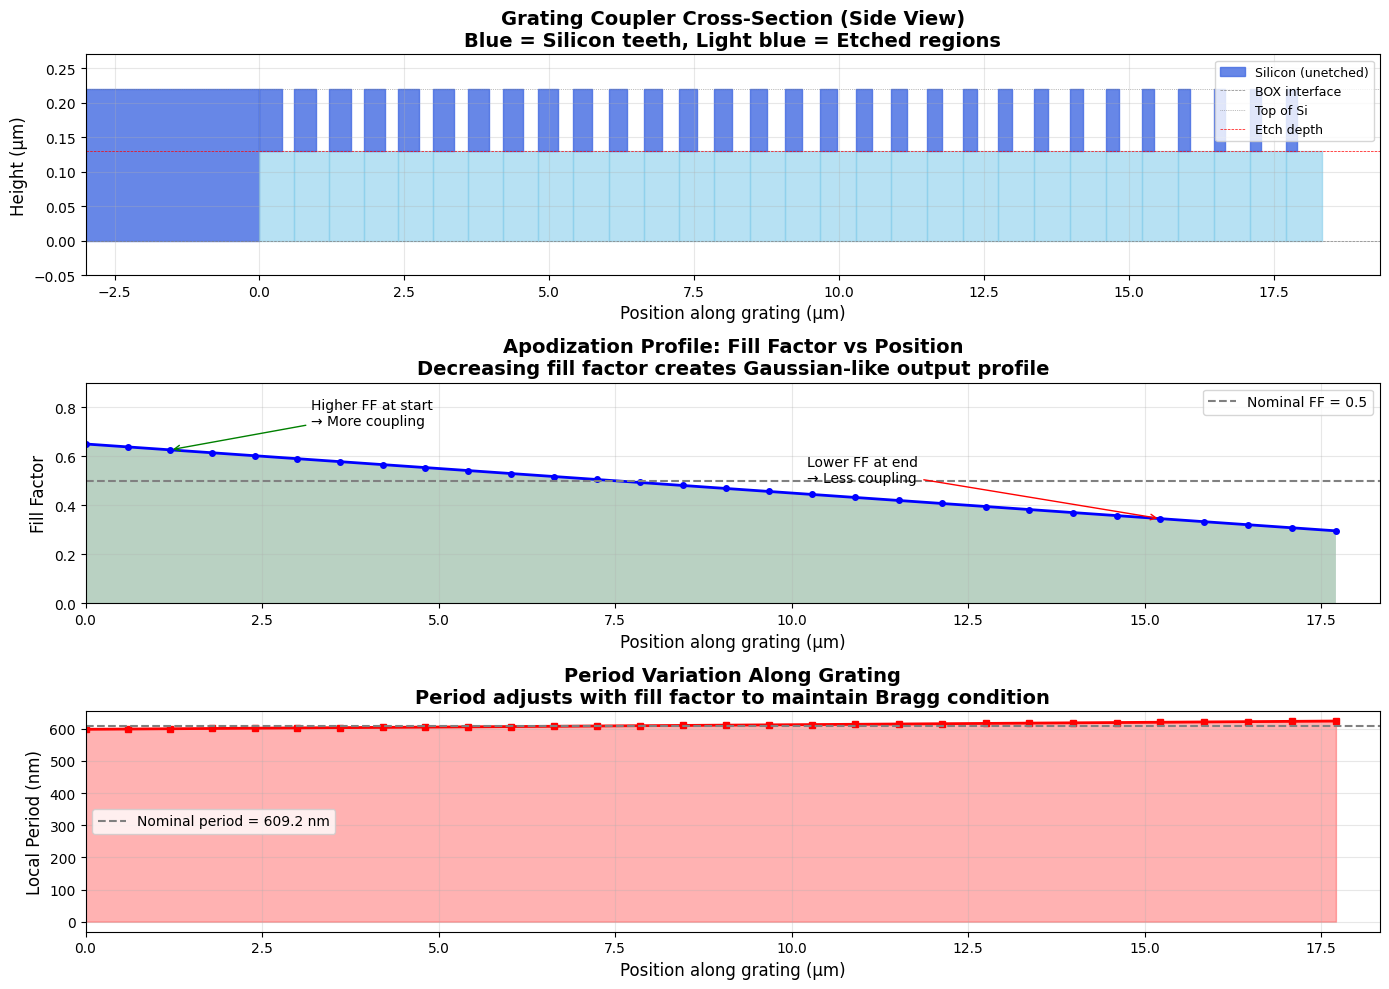


Grating design summary:
  Total length: 18.3 μm
  Number of periods: 30
  Fill factor range: 0.30 to 0.65
  Period range: 598.6 to 624.2 nm

Saved: tutorial_results/01_grating_design.png


In [5]:
def plot_grating_design():
    """
    Visualize the grating coupler design showing the apodization pattern.

    This plot shows:
    - Top: The grating tooth pattern with varying widths
    - Middle: Fill factor vs position (apodization profile)
    - Bottom: Local period vs position
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Calculate grating teeth positions and widths
    theta_rad = np.radians(GRATING_ANGLE)
    f_0 = 0.65  # Initial fill factor

    x_positions = []
    tooth_widths = []
    periods = []
    fill_factors = []
    x_pos = 0

    for i in range(N_PERIODS):
        f_i = max(0.2, min(0.8, f_0 - APOD_R * x_pos))
        n_eff_local = f_i * N_EFF_UNETCHED + (1 - f_i) * N_EFF_ETCHED
        delta_i = WAVELENGTH / (n_eff_local - N_SIO2 * np.sin(theta_rad))
        tooth_width = delta_i * f_i

        x_positions.append(x_pos)
        tooth_widths.append(tooth_width)
        periods.append(delta_i)
        fill_factors.append(f_i)

        x_pos += delta_i

    grating_length = x_pos

    # Plot 1: Grating structure cross-section
    ax1 = axes[0]

    # Draw waveguide (input side)
    ax1.fill_between([-3, 0], 0, H_SI, color='#4169E1', alpha=0.8, label='Silicon (unetched)')

    # Draw grating teeth
    for i, (x, w) in enumerate(zip(x_positions, tooth_widths)):
        # Etched base
        ax1.fill_between([x, x + periods[i]], 0, H_SI - ETCH_DEPTH,
                        color='#87CEEB', alpha=0.6)
        # Unetched tooth
        ax1.fill_between([x, x + w], H_SI - ETCH_DEPTH, H_SI,
                        color='#4169E1', alpha=0.8)

    ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, label='BOX interface')
    ax1.axhline(y=H_SI, color='gray', linestyle=':', linewidth=0.5, label='Top of Si')
    ax1.axhline(y=H_SI - ETCH_DEPTH, color='red', linestyle='--', linewidth=0.5, label='Etch depth')

    ax1.set_xlabel('Position along grating (μm)', fontsize=12)
    ax1.set_ylabel('Height (μm)', fontsize=12)
    ax1.set_title('Grating Coupler Cross-Section (Side View)\n'
                  'Blue = Silicon teeth, Light blue = Etched regions', fontsize=14, fontweight='bold')
    ax1.set_xlim(-3, grating_length + 1)
    ax1.set_ylim(-0.05, H_SI + 0.05)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Fill factor profile (apodization)
    ax2 = axes[1]
    ax2.plot(x_positions, fill_factors, 'b-o', markersize=4, linewidth=2)
    ax2.axhline(y=FILL_FACTOR, color='gray', linestyle='--', label=f'Nominal FF = {FILL_FACTOR}')
    ax2.fill_between(x_positions, fill_factors, alpha=0.3)

    ax2.set_xlabel('Position along grating (μm)', fontsize=12)
    ax2.set_ylabel('Fill Factor', fontsize=12)
    ax2.set_title('Apodization Profile: Fill Factor vs Position\n'
                  'Decreasing fill factor creates Gaussian-like output profile', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, grating_length)
    ax2.set_ylim(0, 0.9)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Add annotation explaining apodization
    ax2.annotate('Higher FF at start\n→ More coupling',
                xy=(x_positions[2], fill_factors[2]),
                xytext=(x_positions[2] + 2, fill_factors[2] + 0.1),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='green'))
    ax2.annotate('Lower FF at end\n→ Less coupling',
                xy=(x_positions[-5], fill_factors[-5]),
                xytext=(x_positions[-5] - 5, fill_factors[-5] + 0.15),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

    # Plot 3: Period variation
    ax3 = axes[2]
    ax3.plot(x_positions, np.array(periods) * 1000, 'r-s', markersize=4, linewidth=2)
    ax3.axhline(y=grating_period * 1000, color='gray', linestyle='--',
                label=f'Nominal period = {grating_period*1000:.1f} nm')
    ax3.fill_between(x_positions, np.array(periods) * 1000, alpha=0.3, color='red')

    ax3.set_xlabel('Position along grating (μm)', fontsize=12)
    ax3.set_ylabel('Local Period (nm)', fontsize=12)
    ax3.set_title('Period Variation Along Grating\n'
                  'Period adjusts with fill factor to maintain Bragg condition', fontsize=14, fontweight='bold')
    ax3.set_xlim(0, grating_length)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "01_grating_design.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nGrating design summary:")
    print(f"  Total length: {grating_length:.1f} μm")
    print(f"  Number of periods: {N_PERIODS}")
    print(f"  Fill factor range: {min(fill_factors):.2f} to {max(fill_factors):.2f}")
    print(f"  Period range: {min(periods)*1000:.1f} to {max(periods)*1000:.1f} nm")
    print(f"\nSaved: {RESULTS_DIR / '01_grating_design.png'}")

    return grating_length

grating_length = plot_grating_design()

### 2.4 Microlens and Fiber Parameters

The microlens is formed at the SiO2/air interface, typically by etching or
molding a curved surface into the silica cladding.

#### Thin Lens Approximation
For a plano-convex lens with radius of curvature R at a refractive interface:

$$f = \frac{R}{n_{lens} - n_{medium}}$$

The lens applies a phase transformation:

$$\phi(x, y) = -\frac{k (x^2 + y^2)}{2f}$$

where $k = 2\pi n / \lambda$ is the wavenumber in the medium.

In [6]:
# Microlens parameters
MICROLENS_RADIUS = 120.0  # Radius of curvature (μm)
SI_LAYER_THICKNESS = 300.0  # Distance: grating to microlens (μm)
MICROLENS_TO_FIBER = 300.0  # Distance: microlens to fiber (μm)

# Calculate focal length (thin lens approximation)
# Light goes from SiO2 (n=1.44) through curved surface to air (n=1.0)
FOCAL_LENGTH = MICROLENS_RADIUS / (N_SIO2 - N_AIR)

# Fiber parameters (expanded core single-mode fiber)
FIBER_BEAM_WAIST = 13.0  # 1/e² intensity radius (μm)
FIBER_MFD = 10.4  # Standard SMF mode field diameter for reference

print(f"\n--- Optical System Parameters ---")
print(f"Microlens radius: {MICROLENS_RADIUS} μm")
print(f"Focal length: {FOCAL_LENGTH:.1f} μm")
print(f"Grating to lens: {SI_LAYER_THICKNESS} μm")
print(f"Lens to fiber: {MICROLENS_TO_FIBER} μm")
print(f"Fiber beam waist: {FIBER_BEAM_WAIST} μm")


--- Optical System Parameters ---
Microlens radius: 120.0 μm
Focal length: 272.7 μm
Grating to lens: 300.0 μm
Lens to fiber: 300.0 μm
Fiber beam waist: 13.0 μm


### 2.5 Visualizing the Optical System

This diagram shows the complete optical path from the waveguide through
the microlens to the fiber.

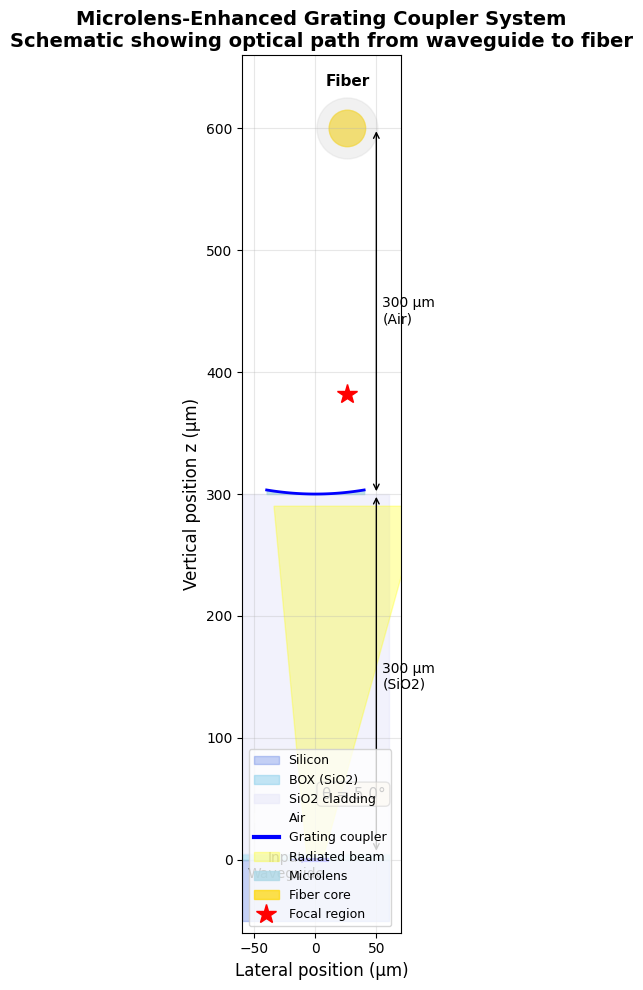


Saved: tutorial_results/02_optical_system_diagram.png


In [7]:
def plot_optical_system_diagram():
    """
    Create a schematic diagram of the complete optical system.

    Shows:
    - Waveguide with grating coupler
    - SiO2 cladding layer
    - Microlens at SiO2/air interface
    - Air gap to fiber
    - Fiber position
    """
    fig, ax = plt.subplots(figsize=(12, 10))

    # Define z-coordinates (vertical)
    z_grating = 0
    z_lens = SI_LAYER_THICKNESS
    z_fiber = SI_LAYER_THICKNESS + MICROLENS_TO_FIBER

    # Draw layers
    # Silicon substrate (below grating)
    ax.fill_between([-60, 60], -50, 0, color='#4169E1', alpha=0.3, label='Silicon')

    # BOX layer
    ax.fill_between([-60, 60], 0, 5, color='#87CEEB', alpha=0.5, label='BOX (SiO2)')

    # SiO2 cladding
    ax.fill_between([-60, 60], 5, z_lens, color='#E6E6FA', alpha=0.5, label='SiO2 cladding')

    # Air above lens
    ax.fill_between([-60, 60], z_lens, z_fiber + 50, color='#FFFFFF', alpha=0.3, label='Air')

    # Draw grating coupler
    grating_x = np.linspace(-grating_length/2, grating_length/2, 100)
    ax.plot(grating_x, np.zeros_like(grating_x), 'b-', linewidth=3, label='Grating coupler')

    # Draw waveguide
    ax.arrow(-grating_length/2 - 10, 0, 8, 0, head_width=5, head_length=2, fc='blue', ec='blue')
    ax.text(-grating_length/2 - 15, -15, 'Input\nWaveguide', fontsize=10, ha='center')

    # Draw radiated beam (cone)
    beam_angle = np.radians(GRATING_ANGLE)
    beam_width_start = grating_length * 0.8
    beam_width_end = beam_width_start + 2 * z_lens * np.tan(np.radians(10))  # Divergence

    # Left edge of beam
    x_left_start = -beam_width_start/2
    x_left_end = z_lens * np.tan(beam_angle) - beam_width_end/2

    # Right edge of beam
    x_right_start = beam_width_start/2
    x_right_end = z_lens * np.tan(beam_angle) + beam_width_end/2

    # Draw beam cone (light radiation)
    from matplotlib.patches import Polygon
    beam_vertices = [
        (x_left_start, 5),
        (x_right_start, 5),
        (x_right_end, z_lens - 10),
        (x_left_end, z_lens - 10)
    ]
    beam_polygon = Polygon(beam_vertices, alpha=0.3, color='yellow', label='Radiated beam')
    ax.add_patch(beam_polygon)

    # Draw microlens
    lens_x = np.linspace(-40, 40, 100)
    lens_curve = z_lens + (lens_x**2) / (2 * MICROLENS_RADIUS) * 0.5  # Exaggerated curvature for visibility
    ax.fill_between(lens_x, z_lens, lens_curve, color='#ADD8E6', alpha=0.8, label='Microlens')
    ax.plot(lens_x, lens_curve, 'b-', linewidth=2)

    # Draw fiber
    fiber_radius = 62.5  # Standard fiber cladding radius (μm), scaled down for plot
    fiber_x_center = z_lens * np.tan(beam_angle)  # Fiber aligned with beam
    fiber_circle = plt.Circle((fiber_x_center, z_fiber), 15, color='#FFD700', alpha=0.7, label='Fiber core')
    ax.add_patch(fiber_circle)
    fiber_cladding = plt.Circle((fiber_x_center, z_fiber), 25, color='#D3D3D3', alpha=0.3)
    ax.add_patch(fiber_cladding)
    ax.text(fiber_x_center, z_fiber + 35, 'Fiber', fontsize=11, ha='center', fontweight='bold')

    # Draw focal point
    focal_z = z_lens + FOCAL_LENGTH * 0.3  # Scaled for visibility
    ax.plot(z_lens * np.tan(beam_angle), focal_z, 'r*', markersize=15, label='Focal region')

    # Add dimension annotations
    # Distance: grating to lens
    ax.annotate('', xy=(50, 5), xytext=(50, z_lens),
                arrowprops=dict(arrowstyle='<->', color='black'))
    ax.text(55, z_lens/2, f'{SI_LAYER_THICKNESS:.0f} μm\n(SiO2)', fontsize=10, va='center')

    # Distance: lens to fiber
    ax.annotate('', xy=(50, z_lens), xytext=(50, z_fiber),
                arrowprops=dict(arrowstyle='<->', color='black'))
    ax.text(55, (z_lens + z_fiber)/2, f'{MICROLENS_TO_FIBER:.0f} μm\n(Air)', fontsize=10, va='center')

    # Grating angle annotation
    ax.annotate(f'θ = {GRATING_ANGLE}°', xy=(5, 50), fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Labels
    ax.set_xlabel('Lateral position (μm)', fontsize=12)
    ax.set_ylabel('Vertical position z (μm)', fontsize=12)
    ax.set_title('Microlens-Enhanced Grating Coupler System\n'
                 'Schematic showing optical path from waveguide to fiber',
                 fontsize=14, fontweight='bold')

    ax.set_xlim(-60, 70)
    ax.set_ylim(-60, z_fiber + 60)
    ax.set_aspect('equal')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "02_optical_system_diagram.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nSaved: {RESULTS_DIR / '02_optical_system_diagram.png'}")

plot_optical_system_diagram()

## 3. Fresnel Propagation Theory

### 3.1 The Angular Spectrum Method

To propagate the electromagnetic field from the grating to the fiber, we use
the Angular Spectrum Method (ASM), which is exact for paraxial beams and
efficient via FFT.

The field at distance z is computed as:

1. **Fourier transform** the input field: $\tilde{E}(k_x, k_y) = \mathcal{F}[E(x, y)]$

2. **Apply transfer function**: $\tilde{E}'(k_x, k_y) = \tilde{E}(k_x, k_y) \cdot H(k_x, k_y, z)$

   where $H(k_x, k_y, z) = \exp(i k_z z)$ and $k_z = \sqrt{k^2 - k_x^2 - k_y^2}$

3. **Inverse Fourier transform**: $E(x, y, z) = \mathcal{F}^{-1}[\tilde{E}'(k_x, k_y)]$

For evanescent waves ($k_x^2 + k_y^2 > k^2$), we set the transfer function to zero.

In [8]:
class FresnelPropagator:
    """
    Implements FFT-based Fresnel propagation using the Angular Spectrum Method.

    This class provides methods for:
    - Free-space beam propagation
    - Tilted beam propagation (for angled grating output)
    - Thin lens phase transformations

    Parameters
    ----------
    wavelength : float
        Wavelength in the medium (μm)
    refractive_index : float
        Refractive index of the propagation medium

    Example
    -------
    >>> propagator = FresnelPropagator(wavelength=1.55, refractive_index=1.44)
    >>> E_out = propagator.propagate(E_in, distance=300, dx=0.5, dy=0.5)
    """

    def __init__(self, wavelength: float, refractive_index: float = 1.0):
        self.wavelength = wavelength
        self.n = refractive_index
        self.k = 2 * np.pi * refractive_index / wavelength

    def propagate(self, E: np.ndarray, distance: float, dx: float, dy: float) -> np.ndarray:
        """
        Propagate field using Angular Spectrum Method.

        Parameters
        ----------
        E : ndarray
            Complex electric field (2D array)
        distance : float
            Propagation distance (μm)
        dx, dy : float
            Grid spacing (μm)

        Returns
        -------
        ndarray
            Propagated field
        """
        ny, nx = E.shape

        # Spatial frequencies
        fx = np.fft.fftfreq(nx, dx)
        fy = np.fft.fftfreq(ny, dy)
        FX, FY = np.meshgrid(fx, fy)

        # Wave vector components
        kx = 2 * np.pi * FX
        ky = 2 * np.pi * FY

        # z-component of wave vector (handle evanescent waves)
        k_sq = self.k**2
        kt_sq = kx**2 + ky**2

        # Propagating waves: k_z is real
        # Evanescent waves: k_z would be imaginary, set to zero (no propagation)
        kz = np.sqrt(np.maximum(k_sq - kt_sq, 0))

        # Transfer function
        H = np.exp(1j * kz * distance)

        # Filter evanescent waves
        H[kt_sq > k_sq] = 0

        # Propagate via FFT
        E_fft = np.fft.fft2(E)
        E_prop = np.fft.ifft2(E_fft * H)

        return E_prop

    def apply_tilt(self, E: np.ndarray, theta_x: float, theta_y: float,
                   x: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Apply a linear phase gradient to tilt the beam.

        This models the tilted output from a grating coupler.

        Parameters
        ----------
        E : ndarray
            Complex electric field
        theta_x, theta_y : float
            Tilt angles in x and y directions (degrees)
        x, y : ndarray
            Coordinate arrays (μm)

        Returns
        -------
        ndarray
            Tilted field
        """
        X, Y = np.meshgrid(x, y)

        # Phase gradient for tilted beam
        kx_tilt = self.k * np.sin(np.radians(theta_x))
        ky_tilt = self.k * np.sin(np.radians(theta_y))

        phase = kx_tilt * X + ky_tilt * Y
        return E * np.exp(1j * phase)


class ThinLens:
    """
    Implements a thin lens phase transformation.

    The lens applies a quadratic phase that focuses or defocuses the beam:

    φ(x, y) = -k(x² + y²) / (2f)

    Parameters
    ----------
    focal_length : float
        Focal length of the lens (μm)
    wavelength : float
        Wavelength in the medium after the lens (μm)
    refractive_index : float
        Refractive index of medium after the lens

    Attributes
    ----------
    radius : float
        Radius of curvature (calculated from focal length)
    """

    def __init__(self, focal_length: float, wavelength: float, refractive_index: float = 1.0):
        self.f = focal_length
        self.wavelength = wavelength
        self.n = refractive_index
        self.k = 2 * np.pi * refractive_index / wavelength
        # Back-calculate radius from focal length
        self.radius = focal_length * (N_SIO2 - refractive_index)

    def apply(self, E: np.ndarray, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Apply thin lens phase transformation.

        Parameters
        ----------
        E : ndarray
            Input field
        x, y : ndarray
            Coordinate arrays (μm)

        Returns
        -------
        ndarray
            Field after lens
        """
        X, Y = np.meshgrid(x, y)

        # Quadratic phase for thin lens
        phase = -self.k * (X**2 + Y**2) / (2 * self.f)

        return E * np.exp(1j * phase)


print("Fresnel propagation classes defined.")

Fresnel propagation classes defined.


### 3.2 Visualizing the Angular Spectrum Method

Let's visualize how the ASM works by showing the spatial and frequency domain
representations of a propagating Gaussian beam.

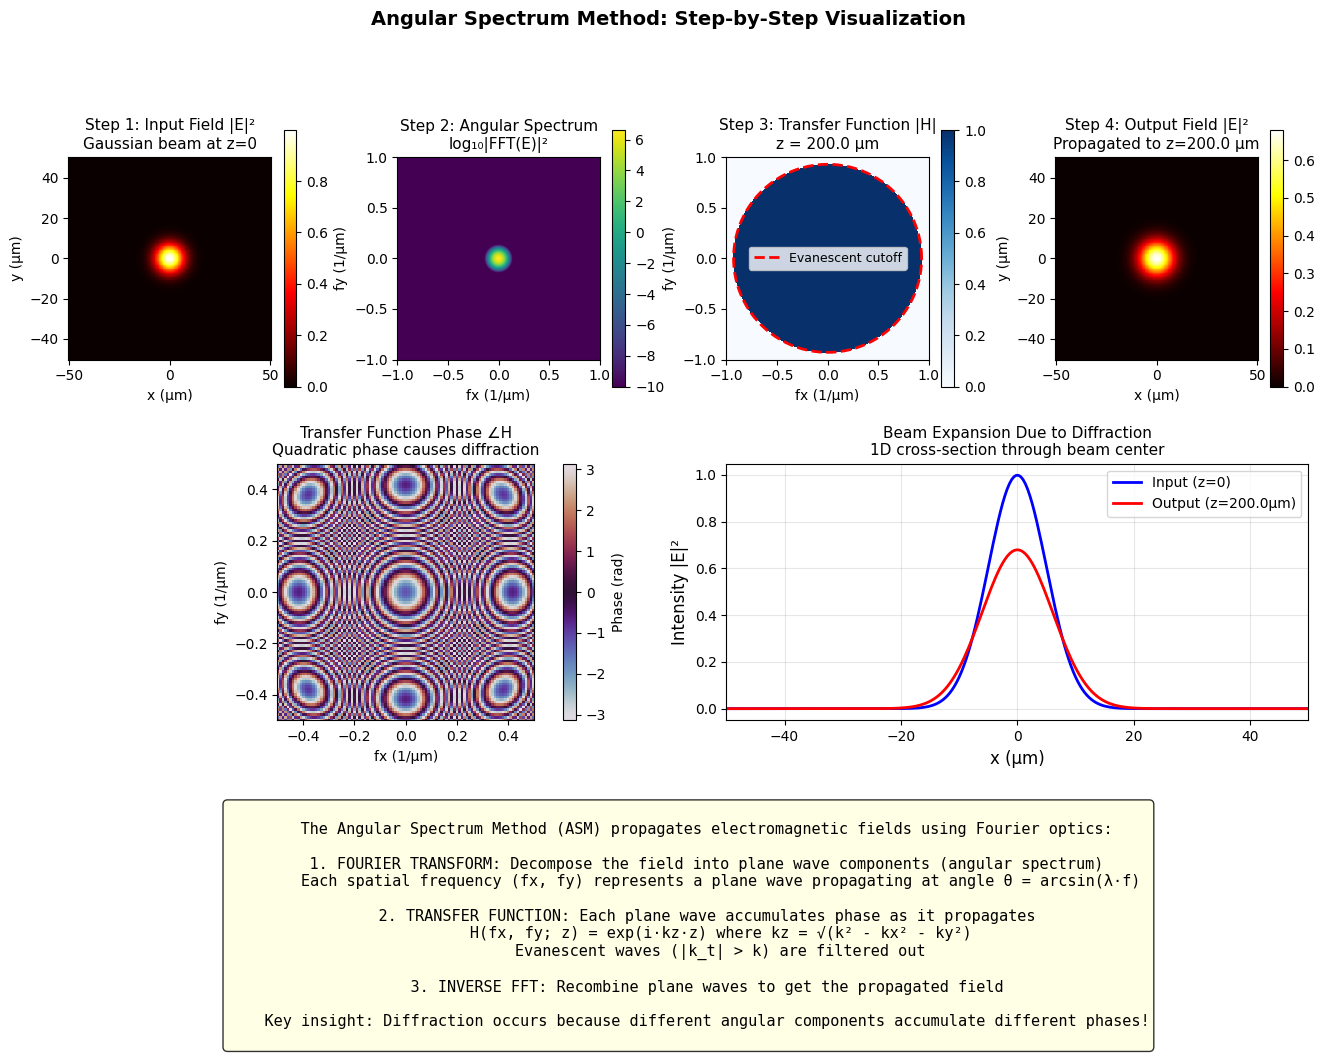


Saved: tutorial_results/03_angular_spectrum_method.png


In [9]:
def demonstrate_angular_spectrum_method():
    """
    Visualize the Angular Spectrum Method step by step.

    Shows:
    - Input Gaussian beam
    - Fourier transform (angular spectrum)
    - Transfer function
    - Output field after propagation
    """
    # Create a simple Gaussian beam
    grid_size = 256
    grid_extent = 100.0
    x = np.linspace(-grid_extent/2, grid_extent/2, grid_size)
    y = np.linspace(-grid_extent/2, grid_extent/2, grid_size)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = np.meshgrid(x, y)

    # Gaussian beam parameters
    waist = 10.0  # μm
    E_in = np.exp(-(X**2 + Y**2) / waist**2)

    # Propagation setup
    propagator = FresnelPropagator(WAVELENGTH, N_SIO2)
    z_prop = 200.0  # μm

    # Step-by-step propagation
    # Step 1: Input field

    # Step 2: Fourier transform
    E_fft = np.fft.fft2(E_in)
    E_fft_shifted = np.fft.fftshift(E_fft)

    # Step 3: Transfer function
    fx = np.fft.fftfreq(grid_size, dx)
    fy = np.fft.fftfreq(grid_size, dy)
    FX, FY = np.meshgrid(fx, fy)
    kx = 2 * np.pi * FX
    ky = 2 * np.pi * FY

    k_sq = propagator.k**2
    kt_sq = kx**2 + ky**2
    kz = np.sqrt(np.maximum(k_sq - kt_sq, 0))
    H = np.exp(1j * kz * z_prop)
    H[kt_sq > k_sq] = 0
    H_shifted = np.fft.fftshift(H)

    # Step 4: Output field
    E_out = propagator.propagate(E_in, z_prop, dx, dy)

    # Create visualization
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 4, figure=fig, hspace=0.3, wspace=0.3)

    # Row 1: Spatial domain
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.pcolormesh(x, y, np.abs(E_in)**2, cmap='hot', shading='auto')
    ax1.set_title('Step 1: Input Field |E|²\nGaussian beam at z=0', fontsize=11)
    ax1.set_xlabel('x (μm)')
    ax1.set_ylabel('y (μm)')
    ax1.set_aspect('equal')
    plt.colorbar(im1, ax=ax1)

    # Row 1: FFT
    ax2 = fig.add_subplot(gs[0, 1])
    fx_shifted = np.fft.fftshift(fx)
    fy_shifted = np.fft.fftshift(fy)
    im2 = ax2.pcolormesh(fx_shifted, fy_shifted, np.log10(np.abs(E_fft_shifted)**2 + 1e-10),
                         cmap='viridis', shading='auto')
    ax2.set_title('Step 2: Angular Spectrum\nlog₁₀|FFT(E)|²', fontsize=11)
    ax2.set_xlabel('fx (1/μm)')
    ax2.set_ylabel('fy (1/μm)')
    ax2.set_aspect('equal')
    ax2.set_xlim(-1, 1)
    ax2.set_ylim(-1, 1)
    plt.colorbar(im2, ax=ax2)

    # Row 1: Transfer function magnitude
    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.pcolormesh(fx_shifted, fy_shifted, np.abs(H_shifted), cmap='Blues', shading='auto')
    ax3.set_title(f'Step 3: Transfer Function |H|\nz = {z_prop} μm', fontsize=11)
    ax3.set_xlabel('fx (1/μm)')
    ax3.set_ylabel('fy (1/μm)')
    ax3.set_aspect('equal')
    ax3.set_xlim(-1, 1)
    ax3.set_ylim(-1, 1)
    # Draw evanescent wave cutoff circle
    theta_plot = np.linspace(0, 2*np.pi, 100)
    k_cutoff = propagator.k / (2 * np.pi)  # in 1/μm
    ax3.plot(k_cutoff * np.cos(theta_plot), k_cutoff * np.sin(theta_plot), 'r--',
             linewidth=2, label='Evanescent cutoff')
    ax3.legend(fontsize=9)
    plt.colorbar(im3, ax=ax3)

    # Row 1: Output field
    ax4 = fig.add_subplot(gs[0, 3])
    im4 = ax4.pcolormesh(x, y, np.abs(E_out)**2, cmap='hot', shading='auto')
    ax4.set_title(f'Step 4: Output Field |E|²\nPropagated to z={z_prop} μm', fontsize=11)
    ax4.set_xlabel('x (μm)')
    ax4.set_ylabel('y (μm)')
    ax4.set_aspect('equal')
    plt.colorbar(im4, ax=ax4)

    # Row 2: Phase of transfer function
    ax5 = fig.add_subplot(gs[1, 0:2])
    im5 = ax5.pcolormesh(fx_shifted, fy_shifted, np.angle(H_shifted),
                         cmap='twilight', shading='auto', vmin=-np.pi, vmax=np.pi)
    ax5.set_title('Transfer Function Phase ∠H\nQuadratic phase causes diffraction', fontsize=11)
    ax5.set_xlabel('fx (1/μm)')
    ax5.set_ylabel('fy (1/μm)')
    ax5.set_aspect('equal')
    ax5.set_xlim(-0.5, 0.5)
    ax5.set_ylim(-0.5, 0.5)
    plt.colorbar(im5, ax=ax5, label='Phase (rad)')

    # Row 2: 1D cross-sections
    ax6 = fig.add_subplot(gs[1, 2:4])
    center_idx = grid_size // 2
    ax6.plot(x, np.abs(E_in[center_idx, :])**2, 'b-', linewidth=2, label='Input (z=0)')
    ax6.plot(x, np.abs(E_out[center_idx, :])**2, 'r-', linewidth=2, label=f'Output (z={z_prop}μm)')
    ax6.set_xlabel('x (μm)', fontsize=12)
    ax6.set_ylabel('Intensity |E|²', fontsize=12)
    ax6.set_title('Beam Expansion Due to Diffraction\n1D cross-section through beam center', fontsize=11)
    ax6.legend(fontsize=10)
    ax6.grid(True, alpha=0.3)
    ax6.set_xlim(-50, 50)

    # Row 3: Explanation text
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')
    explanation = """
    The Angular Spectrum Method (ASM) propagates electromagnetic fields using Fourier optics:

    1. FOURIER TRANSFORM: Decompose the field into plane wave components (angular spectrum)
       Each spatial frequency (fx, fy) represents a plane wave propagating at angle θ = arcsin(λ·f)

    2. TRANSFER FUNCTION: Each plane wave accumulates phase as it propagates
       H(fx, fy; z) = exp(i·kz·z) where kz = √(k² - kx² - ky²)
       Evanescent waves (|k_t| > k) are filtered out

    3. INVERSE FFT: Recombine plane waves to get the propagated field

    Key insight: Diffraction occurs because different angular components accumulate different phases!
    """
    ax7.text(0.5, 0.5, explanation, transform=ax7.transAxes, fontsize=11,
             verticalalignment='center', horizontalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
             family='monospace')

    plt.suptitle('Angular Spectrum Method: Step-by-Step Visualization',
                 fontsize=14, fontweight='bold')
    plt.savefig(RESULTS_DIR / "03_angular_spectrum_method.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nSaved: {RESULTS_DIR / '03_angular_spectrum_method.png'}")

demonstrate_angular_spectrum_method()

## 4. Mode Overlap Calculation

### 4.1 Fiber Coupling Efficiency

The coupling efficiency into a single-mode fiber is determined by the overlap
integral between the incident field and the fiber mode:

$$\eta = \frac{|\int E_{beam} \cdot E_{fiber}^* \, dA|^2}
         {\int |E_{beam}|^2 \, dA \cdot \int |E_{fiber}|^2 \, dA}$$

For a Gaussian fiber mode:

$$E_{fiber}(x, y) = \exp\left(-\frac{(x-x_0)^2 + (y-y_0)^2}{w_0^2}\right)$$

where $w_0$ is the beam waist (1/e² intensity radius).

In [10]:
def gaussian_mode(x: np.ndarray, y: np.ndarray, waist: float,
                  center_x: float = 0, center_y: float = 0) -> np.ndarray:
    """
    Generate a Gaussian fiber mode profile.

    Parameters
    ----------
    x, y : ndarray
        Coordinate arrays (μm)
    waist : float
        Beam waist / 1/e² intensity radius (μm)
    center_x, center_y : float
        Mode center position (μm)

    Returns
    -------
    ndarray
        2D Gaussian mode profile (normalized)
    """
    X, Y = np.meshgrid(x, y)
    r_sq = (X - center_x)**2 + (Y - center_y)**2
    E = np.exp(-r_sq / waist**2)

    # Normalize so that integral of |E|² = 1
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    norm = np.sqrt(np.sum(np.abs(E)**2) * dx * dy)

    return E / norm


def calculate_coupling_efficiency(E_beam: np.ndarray, x: np.ndarray, y: np.ndarray,
                                   fiber_waist: float, fiber_offset_x: float = 0,
                                   fiber_offset_y: float = 0) -> float:
    """
    Calculate coupling efficiency into a single-mode fiber.

    Parameters
    ----------
    E_beam : ndarray
        Incident beam field
    x, y : ndarray
        Coordinate arrays (μm)
    fiber_waist : float
        Fiber mode waist (μm)
    fiber_offset_x, fiber_offset_y : float
        Fiber position offset from origin (μm)

    Returns
    -------
    float
        Coupling efficiency (0 to 1)
    """
    # Generate fiber mode
    E_fiber = gaussian_mode(x, y, fiber_waist, fiber_offset_x, fiber_offset_y)

    dx = x[1] - x[0]
    dy = y[1] - y[0]

    # Overlap integral
    overlap = np.sum(E_beam * np.conj(E_fiber)) * dx * dy

    # Normalization
    beam_power = np.sum(np.abs(E_beam)**2) * dx * dy
    fiber_power = np.sum(np.abs(E_fiber)**2) * dx * dy

    # Coupling efficiency
    efficiency = np.abs(overlap)**2 / (beam_power * fiber_power)

    return float(efficiency)


print("Mode overlap functions defined.")

Mode overlap functions defined.


### 4.2 Visualizing Mode Overlap

Let's visualize how the mode overlap integral works and why beam shape matters.

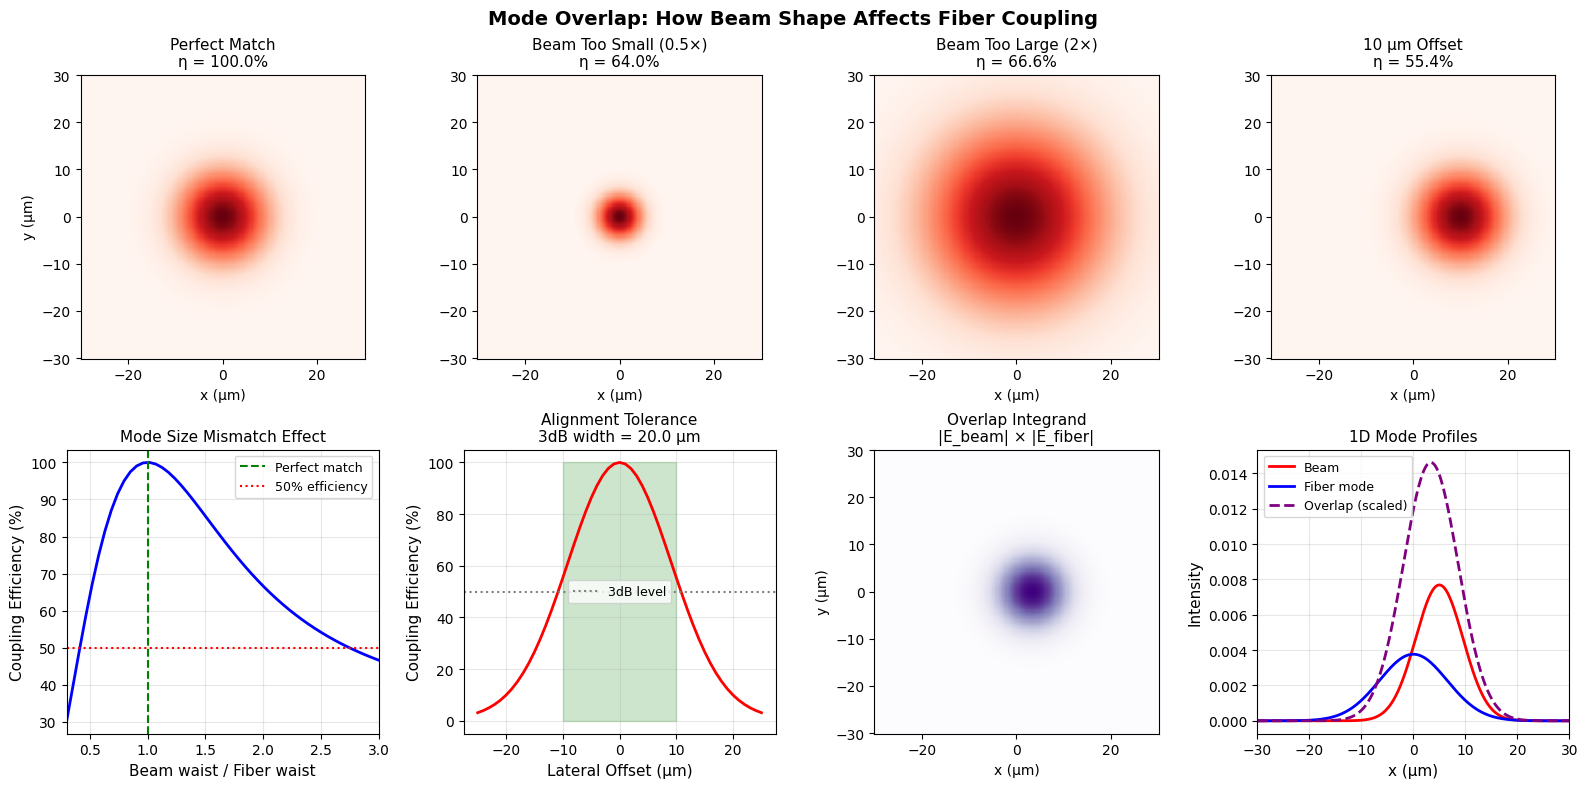


Saved: tutorial_results/04_mode_overlap_concept.png


In [11]:
def demonstrate_mode_overlap():
    """
    Visualize the mode overlap concept with different beam profiles.

    Shows:
    - How overlap integral works
    - Effect of beam waist mismatch
    - Effect of lateral offset
    """
    grid_size = 256
    grid_extent = 60.0
    x = np.linspace(-grid_extent/2, grid_extent/2, grid_size)
    y = np.linspace(-grid_extent/2, grid_extent/2, grid_size)
    X, Y = np.meshgrid(x, y)

    fiber_waist = FIBER_BEAM_WAIST  # 13 μm

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    # Case 1: Perfect match
    E_beam1 = gaussian_mode(x, y, fiber_waist)
    E_fiber = gaussian_mode(x, y, fiber_waist)
    eff1 = calculate_coupling_efficiency(E_beam1, x, y, fiber_waist)

    axes[0, 0].pcolormesh(x, y, np.abs(E_beam1)**2, cmap='Reds', shading='auto')
    axes[0, 0].contour(X, Y, np.abs(E_fiber)**2, levels=[0.135], colors='blue', linewidths=2)
    axes[0, 0].set_title(f'Perfect Match\nη = {eff1*100:.1f}%', fontsize=11)
    axes[0, 0].set_xlabel('x (μm)')
    axes[0, 0].set_ylabel('y (μm)')
    axes[0, 0].set_aspect('equal')

    # Case 2: Beam too small
    E_beam2 = gaussian_mode(x, y, fiber_waist * 0.5)
    eff2 = calculate_coupling_efficiency(E_beam2, x, y, fiber_waist)

    axes[0, 1].pcolormesh(x, y, np.abs(E_beam2)**2, cmap='Reds', shading='auto')
    axes[0, 1].contour(X, Y, np.abs(E_fiber)**2, levels=[0.135], colors='blue', linewidths=2)
    axes[0, 1].set_title(f'Beam Too Small (0.5×)\nη = {eff2*100:.1f}%', fontsize=11)
    axes[0, 1].set_xlabel('x (μm)')
    axes[0, 1].set_aspect('equal')

    # Case 3: Beam too large
    E_beam3 = gaussian_mode(x, y, fiber_waist * 2.0)
    eff3 = calculate_coupling_efficiency(E_beam3, x, y, fiber_waist)

    axes[0, 2].pcolormesh(x, y, np.abs(E_beam3)**2, cmap='Reds', shading='auto')
    axes[0, 2].contour(X, Y, np.abs(E_fiber)**2, levels=[0.135], colors='blue', linewidths=2)
    axes[0, 2].set_title(f'Beam Too Large (2×)\nη = {eff3*100:.1f}%', fontsize=11)
    axes[0, 2].set_xlabel('x (μm)')
    axes[0, 2].set_aspect('equal')

    # Case 4: Lateral offset
    E_beam4 = gaussian_mode(x, y, fiber_waist, center_x=10)
    eff4 = calculate_coupling_efficiency(E_beam4, x, y, fiber_waist)

    axes[0, 3].pcolormesh(x, y, np.abs(E_beam4)**2, cmap='Reds', shading='auto')
    axes[0, 3].contour(X, Y, np.abs(E_fiber)**2, levels=[0.135], colors='blue', linewidths=2)
    axes[0, 3].set_title(f'10 μm Offset\nη = {eff4*100:.1f}%', fontsize=11)
    axes[0, 3].set_xlabel('x (μm)')
    axes[0, 3].set_aspect('equal')

    # Row 2: Quantitative analysis

    # Waist mismatch scan
    waist_ratios = np.linspace(0.3, 3.0, 50)
    eff_waist = []
    for ratio in waist_ratios:
        E = gaussian_mode(x, y, fiber_waist * ratio)
        eff_waist.append(calculate_coupling_efficiency(E, x, y, fiber_waist))

    axes[1, 0].plot(waist_ratios, np.array(eff_waist) * 100, 'b-', linewidth=2)
    axes[1, 0].axvline(x=1.0, color='green', linestyle='--', label='Perfect match')
    axes[1, 0].axhline(y=50, color='red', linestyle=':', label='50% efficiency')
    axes[1, 0].set_xlabel('Beam waist / Fiber waist', fontsize=11)
    axes[1, 0].set_ylabel('Coupling Efficiency (%)', fontsize=11)
    axes[1, 0].set_title('Mode Size Mismatch Effect', fontsize=11)
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0.3, 3.0)

    # Offset scan
    offsets = np.linspace(-25, 25, 51)
    eff_offset = []
    for off in offsets:
        E = gaussian_mode(x, y, fiber_waist, center_x=off)
        eff_offset.append(calculate_coupling_efficiency(E, x, y, fiber_waist))

    axes[1, 1].plot(offsets, np.array(eff_offset) * 100, 'r-', linewidth=2)
    axes[1, 1].axhline(y=50, color='gray', linestyle=':', label='3dB level')
    half_max_idx = np.where(np.array(eff_offset) >= 0.5 * max(eff_offset))[0]
    if len(half_max_idx) > 0:
        tolerance = offsets[half_max_idx[-1]] - offsets[half_max_idx[0]]
        axes[1, 1].fill_between(offsets[half_max_idx], 0, 100, alpha=0.2, color='green')
        axes[1, 1].set_title(f'Alignment Tolerance\n3dB width = {tolerance:.1f} μm', fontsize=11)
    else:
        axes[1, 1].set_title('Alignment Tolerance', fontsize=11)
    axes[1, 1].set_xlabel('Lateral Offset (μm)', fontsize=11)
    axes[1, 1].set_ylabel('Coupling Efficiency (%)', fontsize=11)
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(True, alpha=0.3)

    # Overlap product visualization
    E_beam_viz = gaussian_mode(x, y, fiber_waist * 0.7, center_x=5)
    E_fiber_viz = gaussian_mode(x, y, fiber_waist)
    overlap_product = np.abs(E_beam_viz) * np.abs(E_fiber_viz)

    axes[1, 2].pcolormesh(x, y, overlap_product, cmap='Purples', shading='auto')
    axes[1, 2].set_title('Overlap Integrand\n|E_beam| × |E_fiber|', fontsize=11)
    axes[1, 2].set_xlabel('x (μm)')
    axes[1, 2].set_ylabel('y (μm)')
    axes[1, 2].set_aspect('equal')

    # 1D profiles
    center_idx = grid_size // 2
    axes[1, 3].plot(x, np.abs(E_beam_viz[center_idx, :])**2, 'r-', linewidth=2, label='Beam')
    axes[1, 3].plot(x, np.abs(E_fiber_viz[center_idx, :])**2, 'b-', linewidth=2, label='Fiber mode')
    axes[1, 3].plot(x, overlap_product[center_idx, :] * 3, 'purple', linewidth=2,
                   linestyle='--', label='Overlap (scaled)')
    axes[1, 3].set_xlabel('x (μm)', fontsize=11)
    axes[1, 3].set_ylabel('Intensity', fontsize=11)
    axes[1, 3].set_title('1D Mode Profiles', fontsize=11)
    axes[1, 3].legend(fontsize=9)
    axes[1, 3].grid(True, alpha=0.3)
    axes[1, 3].set_xlim(-30, 30)

    plt.suptitle('Mode Overlap: How Beam Shape Affects Fiber Coupling',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "04_mode_overlap_concept.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nSaved: {RESULTS_DIR / '04_mode_overlap_concept.png'}")

demonstrate_mode_overlap()

## 5. Grating Coupler FDTD Simulation

### 5.1 Building the Simulation

We use Tidy3D to simulate the grating coupler with full-wave accuracy.
The simulation includes:

- **Apodized grating**: Fill factor varies along the length for Gaussian-like output
- **Bottom reflector**: Aluminum mirror to redirect downward radiation upward
- **Mode source**: Injects the fundamental TE mode into the waveguide
- **Field monitor**: Captures the radiated field above the grating

In [12]:
def create_grating_coupler_simulation(direction: str = "out") -> td.Simulation:
    """
    Create a Tidy3D simulation for the grating coupler.

    Parameters
    ----------
    direction : str
        "out" for waveguide-to-free-space, "in" for free-space-to-waveguide

    Returns
    -------
    td.Simulation
        Configured Tidy3D simulation
    """
    # Materials
    si = td.Medium(permittivity=N_SI**2)
    sio2 = td.Medium(permittivity=N_SIO2**2)
    aluminum = td.PECMedium()  # Perfect conductor for bottom reflector

    # Calculate grating length (depends on apodization)
    if USE_APODIZATION:
        # For apodized grating, sum the varying periods
        theta_rad = np.radians(GRATING_ANGLE)
        f_0 = 0.65  # Initial fill factor
        x_pos = 0
        for i in range(N_PERIODS):
            f_i = max(0.2, min(0.8, f_0 - APOD_R * x_pos))
            n_eff_local = f_i * N_EFF_UNETCHED + (1 - f_i) * N_EFF_ETCHED
            delta_i = WAVELENGTH / (n_eff_local - N_SIO2 * np.sin(theta_rad))
            x_pos += delta_i
        grating_length = x_pos
    else:
        grating_length = N_PERIODS * grating_period

    print(f"Grating length: {grating_length:.1f} μm")

    # Simulation domain
    sim_size_x = grating_length + 10.0
    sim_size_y = 0.0  # 2D simulation
    sim_size_z = H_BOX + H_SI + 10.0

    inf_eff = 1e3  # Effectively infinite extent

    # --- Structures ---

    # BOX layer (buried oxide)
    box = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, -H_BOX),
            rmax=(inf_eff, inf_eff, 0)
        ),
        medium=sio2,
    )

    # Bottom reflector (aluminum) - improves upward radiation
    reflector_thickness = 0.1
    bottom_reflector = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, -H_BOX - reflector_thickness),
            rmax=(inf_eff, inf_eff, -H_BOX)
        ),
        medium=aluminum,
    )

    # Silicon substrate
    substrate = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, -inf_eff),
            rmax=(inf_eff, inf_eff, -H_BOX - reflector_thickness)
        ),
        medium=si,
    )

    # Top cladding (SiO2)
    cladding = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, 0),
            rmax=(inf_eff, inf_eff, inf_eff)
        ),
        medium=sio2,
    )

    # Input waveguide (unetched silicon)
    slab_wg = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, 0),
            rmax=(0, inf_eff, H_SI)
        ),
        medium=si,
    )

    # Etched base of grating
    etched_base = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(0, -inf_eff, 0),
            rmax=(grating_length, inf_eff, H_SI - ETCH_DEPTH)
        ),
        medium=si,
    )

    # Grating teeth with apodization
    grating_teeth = []
    if USE_APODIZATION:
        theta_rad = np.radians(GRATING_ANGLE)
        f_0 = 0.65
        x_pos = 0
        for i in range(N_PERIODS):
            f_i = max(0.2, min(0.8, f_0 - APOD_R * x_pos))
            n_eff_local = f_i * N_EFF_UNETCHED + (1 - f_i) * N_EFF_ETCHED
            delta_i = WAVELENGTH / (n_eff_local - N_SIO2 * np.sin(theta_rad))
            tooth_width = delta_i * f_i

            tooth = td.Structure(
                geometry=td.Box(
                    center=(x_pos + tooth_width/2, 0, H_SI - ETCH_DEPTH/2),
                    size=(tooth_width, td.inf, ETCH_DEPTH)
                ),
                medium=si,
            )
            grating_teeth.append(tooth)
            x_pos += delta_i
    else:
        for i in range(N_PERIODS):
            x_start = i * grating_period
            tooth_width = grating_period * FILL_FACTOR
            tooth = td.Structure(
                geometry=td.Box(
                    center=(x_start + tooth_width/2, 0, H_SI - ETCH_DEPTH/2),
                    size=(tooth_width, td.inf, ETCH_DEPTH)
                ),
                medium=si,
            )
            grating_teeth.append(tooth)

    structures = [box, bottom_reflector, substrate, cladding, slab_wg, etched_base] + grating_teeth

    # --- Source and Monitors ---

    if direction == "out":
        # Mode source in waveguide
        source = td.ModeSource(
            center=(-3.0, 0, H_SI/2),
            size=(0, td.inf, 1.5),
            source_time=td.GaussianPulse(freq0=FREQ0, fwidth=FWIDTH),
            direction="+",
            mode_spec=td.ModeSpec(num_modes=1, target_neff=N_SI),
            mode_index=0,
        )

        # Field monitor above grating
        monitor_height = H_SI + 4.5
        field_monitor = td.FieldMonitor(
            center=(grating_length/2, 0, monitor_height),
            size=(grating_length + 8, 0, 0),
            freqs=[FREQ0],
            name="radiated_field",
        )

        # Mode monitor for reflection
        reflection_monitor = td.ModeMonitor(
            center=(-4.0, 0, H_SI/2),
            size=(0, td.inf, 1.5),
            freqs=[FREQ0],
            mode_spec=td.ModeSpec(num_modes=1, target_neff=N_SI),
            name="reflection",
        )

        monitors = [field_monitor, reflection_monitor]
    else:
        raise NotImplementedError("IN direction not implemented in this tutorial")

    # Create simulation
    sim = td.Simulation(
        center=(grating_length/2 - 3, 0, (H_SI - H_BOX)/2),
        size=(sim_size_x, sim_size_y, sim_size_z),
        grid_spec=td.GridSpec.auto(
            wavelength=WAVELENGTH,
            min_steps_per_wvl=20,
        ),
        structures=structures,
        sources=[source],
        monitors=monitors,
        run_time=td.RunTimeSpec(quality_factor=15),
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.periodic(),
            z=td.Boundary.pml(),
        ),
    )

    return sim, grating_length


print("Grating coupler simulation function defined.")

Grating coupler simulation function defined.


### 5.2 Running the FDTD Simulation

We run the simulation on Tidy3D's cloud infrastructure, which provides
high-performance GPU-accelerated FDTD.

In [ ]:
def run_grating_coupler_fdtd(run_simulation: bool = True):
    """
    Run the grating coupler FDTD simulation.

    Parameters
    ----------
    run_simulation : bool
        If True, run on cloud. If False, load from cache.

    Returns
    -------
    dict
        Results including field data and grating length
    """
    print("\n" + "="*60)
    print("GRATING COUPLER FDTD SIMULATION")
    print("="*60)

    # Create simulation
    sim, grating_length = create_grating_coupler_simulation(direction="out")

    # Visualize geometry - multiple views
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Cross-section view
    sim.plot_eps(y=0, ax=axes[0], freq=FREQ0)
    axes[0].set_title("Side View (y=0)\nPermittivity Distribution", fontsize=11)
    axes[0].set_xlabel("x (μm)")
    axes[0].set_ylabel("z (μm)")

    # Zoom in on grating region
    sim.plot_eps(y=0, ax=axes[1], freq=FREQ0)
    axes[1].set_xlim(-2, grating_length + 2)
    axes[1].set_ylim(-0.5, 1.5)
    axes[1].set_title("Zoomed: Grating Region\nShows individual teeth", fontsize=11)
    axes[1].set_xlabel("x (μm)")
    axes[1].set_ylabel("z (μm)")

    # Source and monitor positions
    sim.plot(y=0, ax=axes[2])
    axes[2].set_title("Simulation Layout\nSource and monitor positions", fontsize=11)
    axes[2].set_xlabel("x (μm)")
    axes[2].set_ylabel("z (μm)")

    plt.suptitle("Tidy3D Simulation Setup", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "05_fdtd_simulation_setup.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {RESULTS_DIR / '05_fdtd_simulation_setup.png'}")

    # Run or load simulation
    result_file = RESULTS_DIR / "gc_out.hdf5"

    if run_simulation:
        print("\nRunning Tidy3D simulation...")
        sim_data = web.run(sim, task_name="GC_tutorial", path=str(result_file))
    else:
        print(f"\nLoading cached results from {result_file}")
        sim_data = td.SimulationData.from_hdf5(result_file)

    # Extract field data
    field_data = sim_data["radiated_field"]
    Ey = field_data.Ey.sel(f=FREQ0).values.squeeze()
    x = field_data.Ey.x.values

    # Check field components
    Ex_power = np.sum(np.abs(field_data.Ex.sel(f=FREQ0).values)**2)
    Ey_power = np.sum(np.abs(Ey)**2)
    print(f"\nField powers: |Ex|²={Ex_power:.2e}, |Ey|²={Ey_power:.2e}")
    print("Using Ey (dominant TE component)")

    # Get reflection
    refl_data = sim_data["reflection"]
    refl_amp = refl_data.amps.sel(direction="-", f=FREQ0).values
    reflection = np.abs(refl_amp.item())**2
    print(f"Reflection back into waveguide: {reflection*100:.1f}%")

    # Plot radiated field profile
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Real and imaginary parts
    axes[0, 0].plot(x, np.real(Ey), 'b-', linewidth=1.5, label='Real(Ey)')
    axes[0, 0].plot(x, np.imag(Ey), 'r-', linewidth=1.5, label='Imag(Ey)')
    axes[0, 0].set_xlabel('x (μm)', fontsize=11)
    axes[0, 0].set_ylabel('Field amplitude', fontsize=11)
    axes[0, 0].set_title('Radiated Field Components\nReal and imaginary parts', fontsize=11)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)

    # Intensity profile
    intensity = np.abs(Ey)**2
    axes[0, 1].plot(x, intensity, 'g-', linewidth=2)
    axes[0, 1].fill_between(x, intensity, alpha=0.3)
    axes[0, 1].set_xlabel('x (μm)', fontsize=11)
    axes[0, 1].set_ylabel('Intensity |Ey|²', fontsize=11)
    axes[0, 1].set_title('Radiated Field Intensity\nApodization creates Gaussian-like profile', fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)

    # Phase profile
    phase = np.angle(Ey)
    # Unwrap phase for visualization
    phase_unwrapped = np.unwrap(phase)
    axes[1, 0].plot(x, phase_unwrapped, 'purple', linewidth=2)
    axes[1, 0].set_xlabel('x (μm)', fontsize=11)
    axes[1, 0].set_ylabel('Phase (rad)', fontsize=11)
    axes[1, 0].set_title(f'Field Phase (Unwrapped)\nLinear slope corresponds to {GRATING_ANGLE}° tilt', fontsize=11)
    axes[1, 0].grid(True, alpha=0.3)

    # Annotate the tilted phase
    # Phase gradient = k*sin(theta)
    k_sio2 = 2 * np.pi * N_SIO2 / WAVELENGTH
    expected_slope = k_sio2 * np.sin(np.radians(GRATING_ANGLE))
    x_fit = x[(x > 0) & (x < grating_length)]
    axes[1, 0].plot(x_fit, expected_slope * (x_fit - x_fit[0]) + phase_unwrapped[np.argmin(np.abs(x))],
                   'r--', linewidth=1.5, label=f'Expected slope ({GRATING_ANGLE}° tilt)')
    axes[1, 0].legend(fontsize=9)

    # Spectrum (showing beam profile is not perfectly Gaussian)
    axes[1, 1].semilogy(x, intensity / np.max(intensity), 'g-', linewidth=2, label='FDTD result')

    # Fit a Gaussian for comparison
    x_center = x[np.argmax(intensity)]
    sigma_fit = grating_length / 4  # Approximate beam waist
    gaussian_fit = np.exp(-((x - x_center)**2) / (2 * sigma_fit**2))
    axes[1, 1].semilogy(x, gaussian_fit, 'r--', linewidth=1.5, label=f'Gaussian fit (σ={sigma_fit:.1f}μm)')

    axes[1, 1].set_xlabel('x (μm)', fontsize=11)
    axes[1, 1].set_ylabel('Normalized Intensity (log)', fontsize=11)
    axes[1, 1].set_title('Beam Profile (Log Scale)\nCompare to ideal Gaussian', fontsize=11)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim(1e-4, 2)

    plt.suptitle(f'FDTD Radiated Field Analysis\n'
                 f'Grating length: {grating_length:.1f} μm, Reflection: {reflection*100:.1f}%',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "06_fdtd_radiated_field.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {RESULTS_DIR / '06_fdtd_radiated_field.png'}")

    return {
        "field_1d": Ey,
        "x": x,
        "grating_length": grating_length,
        "reflection": reflection,
        "sim_data": sim_data,
    }


# Run FDTD (set to False to use cached results)
RUN_FDTD = True  # Set to False if you have cached results

fdtd_results = run_grating_coupler_fdtd(run_simulation=RUN_FDTD)


GRATING COUPLER FDTD SIMULATION
Grating length: 18.3 μm


## 6. Beam Propagation Through Microlens System

### 6.1 Propagation Workflow

Now we propagate the grating output through the optical system:

1. **Extend to 2D**: The 2D FDTD gives a 1D field slice; we assume a Gaussian
   profile in the y-direction (perpendicular to propagation)

2. **Apply tilt**: Add phase gradient for the grating output angle

3. **Propagate through SiO2**: 300 μm to the microlens

4. **Apply lens transformation**: Quadratic phase from the microlens

5. **Propagate through air**: 300 μm to the fiber plane

6. **Calculate coupling**: Mode overlap with fiber

In [ ]:
def propagate_through_microlens_system(fdtd_results: dict):
    """
    Propagate the grating output through the microlens to the fiber.

    Parameters
    ----------
    fdtd_results : dict
        Output from run_grating_coupler_fdtd()

    Returns
    -------
    dict
        Propagation results including fields at each plane
    """
    print("\n" + "="*60)
    print("BEAM PROPAGATION THROUGH MICROLENS")
    print("="*60)

    # Extract FDTD field
    E_1d = fdtd_results["field_1d"]
    x_fdtd = fdtd_results["x"]

    # Create 2D propagation grid
    grid_size = 512
    grid_extent = 200.0  # μm
    x = np.linspace(-grid_extent/2, grid_extent/2, grid_size)
    y = np.linspace(-grid_extent/2, grid_extent/2, grid_size)
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    print(f"Propagation grid: {grid_size}x{grid_size}, dx={dx:.2f}μm")

    # Interpolate 1D field to 2D grid (x-direction)
    E_x = np.interp(x, x_fdtd, E_1d, left=0, right=0)

    # Assume Gaussian profile in y (typical for grating couplers)
    y_width = 10.0  # μm, typical grating width
    E_y = np.exp(-y**2 / y_width**2)

    # Create 2D field
    E_grating = np.outer(E_y, E_x)
    E_grating = E_grating / np.max(np.abs(E_grating))  # Normalize

    # Initialize propagators
    propagator_sio2 = FresnelPropagator(WAVELENGTH, N_SIO2)
    propagator_air = FresnelPropagator(WAVELENGTH, N_AIR)
    microlens = ThinLens(FOCAL_LENGTH, WAVELENGTH, N_AIR)

    print(f"Microlens focal length: {FOCAL_LENGTH:.1f} μm")

    # Step 1: Apply tilt for grating output angle
    E_tilted = propagator_sio2.apply_tilt(E_grating, GRATING_ANGLE, 0, x, y)

    # Step 2: Propagate through SiO2 to microlens
    E_before_lens = propagator_sio2.propagate(E_tilted, SI_LAYER_THICKNESS, dx, dy)

    # Step 3: Apply microlens phase transformation
    E_after_lens = microlens.apply(E_before_lens, x, y)

    # Step 4: Propagate through air to fiber plane
    E_at_fiber = propagator_air.propagate(E_after_lens, MICROLENS_TO_FIBER, dx, dy)

    # Find optimal fiber position
    intensity = np.abs(E_at_fiber)**2
    beam_center_x = x[np.argmax(intensity.sum(axis=0))]
    beam_center_y = y[np.argmax(intensity.sum(axis=1))]

    # Scan for optimal coupling position
    offsets = np.linspace(-40, 40, 41)
    efficiencies = [
        calculate_coupling_efficiency(E_at_fiber, x, y, FIBER_BEAM_WAIST,
                                       beam_center_x + off, beam_center_y)
        for off in offsets
    ]
    best_offset = offsets[np.argmax(efficiencies)]
    coupling_eff = np.max(efficiencies)

    print(f"\nBeam center: x={beam_center_x:.1f}μm")
    print(f"Optimal fiber position: x={beam_center_x + best_offset:.1f}μm")
    print(f"Peak coupling efficiency: {coupling_eff*100:.1f}%")
    print(f"Peak coupling (dB): {10*np.log10(coupling_eff+1e-10):.1f} dB")

    # Also calculate without microlens for comparison
    E_tilted_direct = propagator_sio2.apply_tilt(E_grating, GRATING_ANGLE, 0, x, y)
    E_at_interface = propagator_sio2.propagate(E_tilted_direct, SI_LAYER_THICKNESS, dx, dy)
    E_no_lens = propagator_air.propagate(E_at_interface, MICROLENS_TO_FIBER, dx, dy)

    intensity_no_lens = np.abs(E_no_lens)**2
    beam_center_x_no_lens = x[np.argmax(intensity_no_lens.sum(axis=0))]

    efficiencies_no_lens = [
        calculate_coupling_efficiency(E_no_lens, x, y, FIBER_BEAM_WAIST,
                                       beam_center_x_no_lens + off, beam_center_y)
        for off in offsets
    ]
    coupling_no_lens = np.max(efficiencies_no_lens)

    print(f"Coupling without microlens: {coupling_no_lens*100:.1f}%")

    # Store tilt phase for visualization
    X, Y = np.meshgrid(x, y)
    tilt_phase = propagator_sio2.k * np.sin(np.radians(GRATING_ANGLE)) * X
    lens_phase = -microlens.k * (X**2 + Y**2) / (2 * microlens.f)

    return {
        "E_grating": E_grating,
        "E_tilted": E_tilted,
        "E_before_lens": E_before_lens,
        "E_after_lens": E_after_lens,
        "E_at_fiber": E_at_fiber,
        "E_no_lens": E_no_lens,
        "x": x,
        "y": y,
        "tilt_phase": tilt_phase,
        "lens_phase": lens_phase,
        "coupling_with_lens": coupling_eff,
        "coupling_without_lens": coupling_no_lens,
        "beam_center_x": beam_center_x,
        "best_offset": best_offset,
    }


prop_results = propagate_through_microlens_system(fdtd_results)

### 6.2 Visualizing Beam Propagation Step by Step

Let's create detailed visualizations of the beam at each stage of propagation.

In [ ]:
def visualize_propagation_steps(prop_results: dict):
    """
    Create comprehensive visualization of beam propagation through the system.

    Shows:
    - Field intensity at each plane
    - Phase distributions
    - 1D cross-sections
    """
    x = prop_results["x"]
    y = prop_results["y"]
    center_idx = len(y) // 2

    # === Figure 1: Field intensity evolution ===
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    fields_and_labels = [
        (prop_results["E_grating"], "1. Grating Output\nz = 0"),
        (prop_results["E_tilted"], f"2. After Tilt ({GRATING_ANGLE}°)\nz = 0"),
        (prop_results["E_before_lens"], f"3. Before Microlens\nz = {SI_LAYER_THICKNESS} μm"),
        (prop_results["E_after_lens"], f"4. After Microlens\nz = {SI_LAYER_THICKNESS} μm"),
        (prop_results["E_at_fiber"], f"5. At Fiber (with lens)\nz = {SI_LAYER_THICKNESS + MICROLENS_TO_FIBER} μm"),
        (prop_results["E_no_lens"], f"6. At Fiber (no lens)\nz = {SI_LAYER_THICKNESS + MICROLENS_TO_FIBER} μm"),
    ]

    for ax, (E, label) in zip(axes.flat, fields_and_labels):
        intensity = np.abs(E)**2
        # Normalize each for visibility
        intensity_norm = intensity / np.max(intensity)
        im = ax.pcolormesh(x, y, intensity_norm, cmap='hot', shading='auto', vmin=0, vmax=1)
        ax.set_xlabel('x (μm)', fontsize=10)
        ax.set_ylabel('y (μm)', fontsize=10)
        ax.set_title(label, fontsize=11)
        ax.set_aspect('equal')
        ax.set_xlim(-60, 60)
        ax.set_ylim(-60, 60)
        plt.colorbar(im, ax=ax, label='Normalized |E|²')

    plt.suptitle('Beam Propagation: Intensity at Each Stage\n'
                 'Hot colormap shows field intensity distribution',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "07_propagation_intensity.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {RESULTS_DIR / '07_propagation_intensity.png'}")

    # === Figure 2: Phase distributions ===
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Raw phases
    phases = [
        (np.angle(prop_results["E_grating"]), "1. Grating Output Phase"),
        (prop_results["tilt_phase"], f"2. Applied Tilt Phase\n({GRATING_ANGLE}° angle)"),
        (np.angle(prop_results["E_before_lens"]), "3. Phase Before Lens"),
        (prop_results["lens_phase"], f"4. Lens Phase\n(f = {FOCAL_LENGTH:.0f} μm)"),
        (np.angle(prop_results["E_after_lens"]), "5. Phase After Lens"),
        (np.angle(prop_results["E_at_fiber"]), "6. Phase at Fiber"),
    ]

    for ax, (phase, label) in zip(axes.flat, phases):
        im = ax.pcolormesh(x, y, np.mod(phase + np.pi, 2*np.pi) - np.pi,
                          cmap='twilight', shading='auto', vmin=-np.pi, vmax=np.pi)
        ax.set_xlabel('x (μm)', fontsize=10)
        ax.set_ylabel('y (μm)', fontsize=10)
        ax.set_title(label, fontsize=11)
        ax.set_aspect('equal')
        ax.set_xlim(-60, 60)
        ax.set_ylim(-60, 60)
        plt.colorbar(im, ax=ax, label='Phase (rad)')

    plt.suptitle('Beam Propagation: Phase at Each Stage\n'
                 'Twilight colormap shows phase from -π to +π',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "08_propagation_phase.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {RESULTS_DIR / '08_propagation_phase.png'}")

    # === Figure 3: 1D cross-sections ===
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # X cross-section evolution
    ax1 = axes[0, 0]
    ax1.plot(x, np.abs(prop_results["E_grating"][center_idx, :])**2, 'b-',
             linewidth=2, label='Grating output')
    ax1.plot(x, np.abs(prop_results["E_before_lens"][center_idx, :])**2, 'g-',
             linewidth=2, label='Before lens')
    ax1.plot(x, np.abs(prop_results["E_at_fiber"][center_idx, :])**2, 'r-',
             linewidth=2, label='At fiber (with lens)')
    ax1.set_xlabel('x (μm)', fontsize=12)
    ax1.set_ylabel('Intensity |E|²', fontsize=12)
    ax1.set_title('Beam Profile Evolution (x-direction)\nNote: beam shifts due to tilt angle', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-80, 80)

    # Y cross-section evolution
    ax2 = axes[0, 1]
    x_max_idx = np.argmax(np.abs(prop_results["E_at_fiber"]).sum(axis=0))
    ax2.plot(y, np.abs(prop_results["E_grating"][:, len(x)//2])**2, 'b-',
             linewidth=2, label='Grating output')
    ax2.plot(y, np.abs(prop_results["E_before_lens"][:, len(x)//2])**2, 'g-',
             linewidth=2, label='Before lens')
    ax2.plot(y, np.abs(prop_results["E_at_fiber"][:, x_max_idx])**2, 'r-',
             linewidth=2, label='At fiber (with lens)')
    ax2.set_xlabel('y (μm)', fontsize=12)
    ax2.set_ylabel('Intensity |E|²', fontsize=12)
    ax2.set_title('Beam Profile Evolution (y-direction)\nFocusing by microlens visible', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(-60, 60)

    # Comparison: with vs without lens
    ax3 = axes[1, 0]
    ax3.plot(x, np.abs(prop_results["E_at_fiber"][center_idx, :])**2, 'b-',
             linewidth=2, label='With microlens')
    ax3.plot(x, np.abs(prop_results["E_no_lens"][center_idx, :])**2, 'r--',
             linewidth=2, label='Without microlens')

    # Add fiber mode for reference
    E_fiber = gaussian_mode(x, y, FIBER_BEAM_WAIST, prop_results["beam_center_x"] + prop_results["best_offset"])
    ax3.plot(x, np.abs(E_fiber[center_idx, :])**2 * np.max(np.abs(prop_results["E_at_fiber"])**2) * 0.5,
             'g:', linewidth=2, label='Fiber mode (scaled)')

    ax3.set_xlabel('x (μm)', fontsize=12)
    ax3.set_ylabel('Intensity |E|²', fontsize=12)
    ax3.set_title('Effect of Microlens\nLens reshapes beam for better fiber coupling', fontsize=11)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(-80, 80)

    # Summary metrics
    ax4 = axes[1, 1]
    ax4.axis('off')

    summary_text = f"""
    PROPAGATION SUMMARY
    ==================

    Grating Output Angle: {GRATING_ANGLE}°

    Propagation Distances:
    • Grating → Lens: {SI_LAYER_THICKNESS} μm (in SiO2, n={N_SIO2})
    • Lens → Fiber:   {MICROLENS_TO_FIBER} μm (in Air, n={N_AIR})

    Microlens Parameters:
    • Radius of curvature: {MICROLENS_RADIUS} μm
    • Focal length: {FOCAL_LENGTH:.1f} μm

    Results:
    • Coupling WITH lens:    {prop_results['coupling_with_lens']*100:.1f}%
    • Coupling WITHOUT lens: {prop_results['coupling_without_lens']*100:.1f}%
    • Improvement: {prop_results['coupling_with_lens']/max(prop_results['coupling_without_lens'], 1e-10):.1f}x

    • Beam center at fiber: x = {prop_results['beam_center_x']:.1f} μm
    • Optimal fiber offset: {prop_results['best_offset']:.1f} μm
    """

    ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes, fontsize=11,
             verticalalignment='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    plt.suptitle('Beam Profile Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "09_beam_profiles.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {RESULTS_DIR / '09_beam_profiles.png'}")


visualize_propagation_steps(prop_results)

## 7. Alignment Tolerance Analysis

### 7.1 Why Tolerance Matters

In photonic packaging, fibers must be aligned to chips with micron precision.
The 3dB tolerance is defined as the lateral offset at which coupling drops
by half (-3dB). A larger tolerance means:

- Easier assembly
- Lower packaging cost
- Better reliability (less sensitive to thermal expansion, vibration)

In [ ]:
def analyze_alignment_tolerance(prop_results: dict):
    """
    Analyze alignment tolerance with and without microlens.

    Parameters
    ----------
    prop_results : dict
        Output from propagate_through_microlens_system()

    Returns
    -------
    dict
        Tolerance analysis results
    """
    print("\n" + "="*60)
    print("ALIGNMENT TOLERANCE ANALYSIS")
    print("="*60)

    x = prop_results["x"]
    y = prop_results["y"]
    E_with_lens = prop_results["E_at_fiber"]
    E_no_lens = prop_results["E_no_lens"]
    beam_center = prop_results["beam_center_x"]

    # Scan range
    offsets = np.linspace(-40, 40, 81)

    # Calculate efficiency vs offset for both cases
    eff_with_lens = np.array([
        calculate_coupling_efficiency(E_with_lens, x, y, FIBER_BEAM_WAIST,
                                       beam_center + off, 0)
        for off in offsets
    ])

    # Find beam center for no-lens case
    intensity_no_lens = np.abs(E_no_lens)**2
    beam_center_no_lens = x[np.argmax(intensity_no_lens.sum(axis=0))]

    eff_no_lens = np.array([
        calculate_coupling_efficiency(E_no_lens, x, y, FIBER_BEAM_WAIST,
                                       beam_center_no_lens + off, 0)
        for off in offsets
    ])

    # Calculate 3dB tolerance
    def find_3db_tolerance(efficiency_curve, offsets):
        """Find the half-width at half-maximum."""
        peak = np.max(efficiency_curve)
        half_max = peak / 2

        # Find points where efficiency crosses half-max
        above_half = efficiency_curve >= half_max

        if not np.any(above_half):
            return 0.0

        # Find extent of region above half-max
        indices = np.where(above_half)[0]
        width = offsets[indices[-1]] - offsets[indices[0]]

        return width / 2  # Return half-width (tolerance)

    tolerance_with_lens = find_3db_tolerance(eff_with_lens, offsets)
    tolerance_no_lens = find_3db_tolerance(eff_no_lens, offsets)
    improvement = tolerance_with_lens / tolerance_no_lens if tolerance_no_lens > 0 else 0

    print(f"\n3dB Tolerance WITH microlens: {tolerance_with_lens:.1f} μm")
    print(f"3dB Tolerance WITHOUT microlens: {tolerance_no_lens:.1f} μm")
    print(f"Improvement factor: {improvement:.1f}x")

    return {
        "offsets": offsets,
        "efficiency_with_lens": eff_with_lens,
        "efficiency_no_lens": eff_no_lens,
        "tolerance_with_lens": tolerance_with_lens,
        "tolerance_no_lens": tolerance_no_lens,
        "improvement": improvement,
    }


tolerance_results = analyze_alignment_tolerance(prop_results)

### 7.2 Visualizing Alignment Tolerance

Comprehensive visualization of alignment tolerance analysis.

In [ ]:
def visualize_tolerance_analysis(prop_results: dict, tolerance_results: dict):
    """
    Create detailed visualization of alignment tolerance results.
    """
    x = prop_results["x"]
    y = prop_results["y"]
    offsets = tolerance_results["offsets"]
    eff_with_lens = tolerance_results["efficiency_with_lens"]
    eff_no_lens = tolerance_results["efficiency_no_lens"]

    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

    # === Row 1: Tolerance curves ===

    # Linear scale
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(offsets, eff_with_lens * 100, 'b-', linewidth=2.5, label='With microlens')
    ax1.plot(offsets, eff_no_lens * 100, 'r--', linewidth=2.5, label='Without microlens')
    ax1.axhline(y=np.max(eff_with_lens) * 50, color='blue', linestyle=':', alpha=0.7)
    ax1.axhline(y=np.max(eff_no_lens) * 50, color='red', linestyle=':', alpha=0.7)
    ax1.set_xlabel('Fiber Lateral Offset (μm)', fontsize=11)
    ax1.set_ylabel('Coupling Efficiency (%)', fontsize=11)
    ax1.set_title('Alignment Tolerance (Linear Scale)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-40, 40)
    ax1.set_ylim(0, max(np.max(eff_with_lens), np.max(eff_no_lens)) * 110)

    # Shade 3dB regions
    above_half_lens = eff_with_lens >= np.max(eff_with_lens) * 0.5
    above_half_no_lens = eff_no_lens >= np.max(eff_no_lens) * 0.5
    ax1.fill_between(offsets, 0, eff_with_lens * 100, where=above_half_lens,
                     alpha=0.2, color='blue', label='3dB bandwidth (lens)')

    # dB scale
    ax2 = fig.add_subplot(gs[0, 1])
    eff_db_lens = 10 * np.log10(eff_with_lens + 1e-10)
    eff_db_no_lens = 10 * np.log10(eff_no_lens + 1e-10)

    ax2.plot(offsets, eff_db_lens, 'b-', linewidth=2.5, label='With microlens')
    ax2.plot(offsets, eff_db_no_lens, 'r--', linewidth=2.5, label='Without microlens')
    ax2.axhline(y=np.max(eff_db_lens) - 3, color='blue', linestyle=':',
                label=f'-3dB level (lens)', alpha=0.7)
    ax2.axhline(y=np.max(eff_db_no_lens) - 3, color='red', linestyle=':',
                label=f'-3dB level (no lens)', alpha=0.7)
    ax2.set_xlabel('Fiber Lateral Offset (μm)', fontsize=11)
    ax2.set_ylabel('Coupling Efficiency (dB)', fontsize=11)
    ax2.set_title('Alignment Tolerance (dB Scale)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(-40, 40)
    ax2.set_ylim(-25, 0)

    # Tolerance comparison bar chart
    ax3 = fig.add_subplot(gs[0, 2])
    categories = ['With\nMicrolens', 'Without\nMicrolens']
    tolerances = [tolerance_results["tolerance_with_lens"], tolerance_results["tolerance_no_lens"]]
    colors = ['steelblue', 'coral']
    bars = ax3.bar(categories, tolerances, color=colors, edgecolor='black', linewidth=1.5)

    # Add value labels
    for bar, val in zip(bars, tolerances):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f} μm', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax3.set_ylabel('3dB Tolerance (μm)', fontsize=11)
    ax3.set_title(f'Tolerance Comparison\nImprovement: {tolerance_results["improvement"]:.1f}x',
                 fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # === Row 2: 2D coupling maps ===

    # Coupling map with lens
    ax4 = fig.add_subplot(gs[1, 0])
    offset_x = np.linspace(-30, 30, 31)
    offset_y = np.linspace(-30, 30, 31)
    coupling_map_lens = np.zeros((len(offset_y), len(offset_x)))

    E_with_lens = prop_results["E_at_fiber"]
    beam_center = prop_results["beam_center_x"]

    for i, oy in enumerate(offset_y):
        for j, ox in enumerate(offset_x):
            coupling_map_lens[i, j] = calculate_coupling_efficiency(
                E_with_lens, x, y, FIBER_BEAM_WAIST, beam_center + ox, oy
            )

    im4 = ax4.pcolormesh(offset_x, offset_y, coupling_map_lens * 100,
                         cmap='viridis', shading='auto')
    ax4.contour(offset_x, offset_y, coupling_map_lens * 100,
                levels=[np.max(coupling_map_lens) * 50], colors='white', linewidths=2)
    ax4.set_xlabel('X Offset (μm)', fontsize=11)
    ax4.set_ylabel('Y Offset (μm)', fontsize=11)
    ax4.set_title('2D Coupling Map (With Lens)\nWhite contour: 3dB level', fontsize=11)
    ax4.set_aspect('equal')
    plt.colorbar(im4, ax=ax4, label='Efficiency (%)')

    # Coupling map without lens
    ax5 = fig.add_subplot(gs[1, 1])
    coupling_map_no_lens = np.zeros((len(offset_y), len(offset_x)))

    E_no_lens = prop_results["E_no_lens"]
    intensity_no_lens = np.abs(E_no_lens)**2
    beam_center_no_lens = x[np.argmax(intensity_no_lens.sum(axis=0))]

    for i, oy in enumerate(offset_y):
        for j, ox in enumerate(offset_x):
            coupling_map_no_lens[i, j] = calculate_coupling_efficiency(
                E_no_lens, x, y, FIBER_BEAM_WAIST, beam_center_no_lens + ox, oy
            )

    im5 = ax5.pcolormesh(offset_x, offset_y, coupling_map_no_lens * 100,
                         cmap='viridis', shading='auto')
    ax5.contour(offset_x, offset_y, coupling_map_no_lens * 100,
                levels=[np.max(coupling_map_no_lens) * 50], colors='white', linewidths=2)
    ax5.set_xlabel('X Offset (μm)', fontsize=11)
    ax5.set_ylabel('Y Offset (μm)', fontsize=11)
    ax5.set_title('2D Coupling Map (No Lens)\nWhite contour: 3dB level', fontsize=11)
    ax5.set_aspect('equal')
    plt.colorbar(im5, ax=ax5, label='Efficiency (%)')

    # Difference map
    ax6 = fig.add_subplot(gs[1, 2])
    diff_map = coupling_map_lens - coupling_map_no_lens
    im6 = ax6.pcolormesh(offset_x, offset_y, diff_map * 100,
                         cmap='RdBu', shading='auto',
                         vmin=-np.max(np.abs(diff_map)) * 100,
                         vmax=np.max(np.abs(diff_map)) * 100)
    ax6.set_xlabel('X Offset (μm)', fontsize=11)
    ax6.set_ylabel('Y Offset (μm)', fontsize=11)
    ax6.set_title('Improvement Map (Lens - No Lens)\nBlue: lens helps, Red: lens hurts', fontsize=11)
    ax6.set_aspect('equal')
    plt.colorbar(im6, ax=ax6, label='Δ Efficiency (%)')

    # === Row 3: Physical interpretation ===

    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')

    interpretation = f"""
    PHYSICAL INTERPRETATION OF RESULTS
    ===================================

    WHY THE MICROLENS IMPROVES TOLERANCE:

    Without microlens:
    • The grating coupler output is a tilted, expanding Gaussian beam
    • Beam size at fiber plane: ~{grating_length:.0f} μm (same as grating length)
    • Strong diffraction causes beam to spread significantly
    • Fiber mode: {FIBER_BEAM_WAIST} μm waist (1/e² radius)
    • Poor size match → low coupling efficiency
    • Sharp coupling curve → small tolerance ({tolerance_results['tolerance_no_lens']:.1f} μm)

    With microlens:
    • Microlens (f = {FOCAL_LENGTH:.0f} μm) partially focuses the beam
    • Beam is reshaped to better match fiber mode size
    • Phase front is modified for better mode overlap
    • Coupling curve is broader → larger tolerance ({tolerance_results['tolerance_with_lens']:.1f} μm)

    KEY INSIGHT:
    The lens doesn't simply "focus" the beam - it transforms the beam profile
    to better match the Gaussian fiber mode across a wider range of positions.
    This is the key to improved alignment tolerance!

    PRACTICAL IMPLICATIONS:
    • {tolerance_results['improvement']:.1f}x larger tolerance → easier fiber alignment
    • Lower packaging costs (less precision required)
    • Better thermal stability (less sensitive to drift)
    • Enables passive alignment techniques
    """

    ax7.text(0.02, 0.98, interpretation, transform=ax7.transAxes, fontsize=10,
             verticalalignment='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    plt.suptitle('Alignment Tolerance Analysis: Microlens Impact on Fiber Coupling',
                 fontsize=14, fontweight='bold')
    plt.savefig(RESULTS_DIR / "10_tolerance_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {RESULTS_DIR / '10_tolerance_analysis.png'}")


visualize_tolerance_analysis(prop_results, tolerance_results)

## 8. Final Results Summary

### 8.1 Comprehensive Results Visualization

In [ ]:
def create_final_summary(fdtd_results: dict, prop_results: dict, tolerance_results: dict):
    """
    Create a comprehensive summary figure with all key results.
    """
    fig = plt.figure(figsize=(18, 14))
    gs = GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.4)

    x = prop_results["x"]
    y = prop_results["y"]
    center_idx = len(y) // 2

    # === Title row ===
    ax_title = fig.add_subplot(gs[0, :2])
    ax_title.axis('off')
    title_text = """
    MULTI-SCALE SIMULATION RESULTS
    Microlens-Enhanced Grating Coupler

    This tutorial demonstrated:
    • Tidy3D FDTD for accurate grating coupler simulation
    • FFT-based Fresnel propagation for bulk optics
    • Mode overlap calculation for fiber coupling
    • Alignment tolerance analysis
    """
    ax_title.text(0.05, 0.9, title_text, transform=ax_title.transAxes, fontsize=12,
                 verticalalignment='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    # Design parameters
    ax_params = fig.add_subplot(gs[0, 2:])
    ax_params.axis('off')
    params_text = f"""
    DESIGN PARAMETERS

    Grating Coupler:
    • Wavelength: {WAVELENGTH} μm
    • Periods: {N_PERIODS}
    • Etch depth: {ETCH_DEPTH*1000:.0f} nm
    • Output angle: {GRATING_ANGLE}°
    • Apodization: {'Yes' if USE_APODIZATION else 'No'}

    Optical System:
    • Microlens radius: {MICROLENS_RADIUS} μm
    • Focal length: {FOCAL_LENGTH:.0f} μm
    • Grating-to-lens: {SI_LAYER_THICKNESS} μm
    • Lens-to-fiber: {MICROLENS_TO_FIBER} μm
    • Fiber waist: {FIBER_BEAM_WAIST} μm
    """
    ax_params.text(0.05, 0.9, params_text, transform=ax_params.transAxes, fontsize=10,
                  verticalalignment='top', family='monospace',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # === Row 2: Beam evolution ===
    ax_beam1 = fig.add_subplot(gs[1, 0])
    intensity = np.abs(prop_results["E_grating"])**2
    ax_beam1.pcolormesh(x, y, intensity / np.max(intensity), cmap='hot', shading='auto')
    ax_beam1.set_title('Grating Output', fontsize=11)
    ax_beam1.set_xlabel('x (μm)')
    ax_beam1.set_ylabel('y (μm)')
    ax_beam1.set_aspect('equal')
    ax_beam1.set_xlim(-40, 40)
    ax_beam1.set_ylim(-40, 40)

    ax_beam2 = fig.add_subplot(gs[1, 1])
    intensity = np.abs(prop_results["E_before_lens"])**2
    ax_beam2.pcolormesh(x, y, intensity / np.max(intensity), cmap='hot', shading='auto')
    ax_beam2.set_title('Before Lens', fontsize=11)
    ax_beam2.set_xlabel('x (μm)')
    ax_beam2.set_aspect('equal')
    ax_beam2.set_xlim(-40, 40)
    ax_beam2.set_ylim(-40, 40)

    ax_beam3 = fig.add_subplot(gs[1, 2])
    intensity = np.abs(prop_results["E_at_fiber"])**2
    ax_beam3.pcolormesh(x, y, intensity / np.max(intensity), cmap='hot', shading='auto')
    ax_beam3.set_title('At Fiber (with lens)', fontsize=11)
    ax_beam3.set_xlabel('x (μm)')
    ax_beam3.set_aspect('equal')
    ax_beam3.set_xlim(-40, 40)
    ax_beam3.set_ylim(-40, 40)

    ax_beam4 = fig.add_subplot(gs[1, 3])
    intensity = np.abs(prop_results["E_no_lens"])**2
    ax_beam4.pcolormesh(x, y, intensity / np.max(intensity), cmap='hot', shading='auto')
    ax_beam4.set_title('At Fiber (no lens)', fontsize=11)
    ax_beam4.set_xlabel('x (μm)')
    ax_beam4.set_aspect('equal')
    ax_beam4.set_xlim(-40, 40)
    ax_beam4.set_ylim(-40, 40)

    # === Row 3: Analysis plots ===

    # FDTD field
    ax_fdtd = fig.add_subplot(gs[2, 0])
    ax_fdtd.plot(fdtd_results["x"], np.abs(fdtd_results["field_1d"])**2, 'b-', linewidth=1.5)
    ax_fdtd.fill_between(fdtd_results["x"], np.abs(fdtd_results["field_1d"])**2, alpha=0.3)
    ax_fdtd.set_xlabel('x (μm)', fontsize=10)
    ax_fdtd.set_ylabel('|Ey|²', fontsize=10)
    ax_fdtd.set_title('FDTD Radiated Field', fontsize=11)
    ax_fdtd.grid(True, alpha=0.3)

    # Beam profiles comparison
    ax_profiles = fig.add_subplot(gs[2, 1])
    ax_profiles.plot(x, np.abs(prop_results["E_at_fiber"][center_idx, :])**2, 'b-',
                    linewidth=2, label='With lens')
    ax_profiles.plot(x, np.abs(prop_results["E_no_lens"][center_idx, :])**2, 'r--',
                    linewidth=2, label='No lens')
    ax_profiles.set_xlabel('x (μm)', fontsize=10)
    ax_profiles.set_ylabel('Intensity', fontsize=10)
    ax_profiles.set_title('Beam Profile at Fiber', fontsize=11)
    ax_profiles.legend(fontsize=9)
    ax_profiles.grid(True, alpha=0.3)
    ax_profiles.set_xlim(-60, 60)

    # Tolerance curves
    ax_tol = fig.add_subplot(gs[2, 2])
    ax_tol.plot(tolerance_results["offsets"], tolerance_results["efficiency_with_lens"] * 100,
               'b-', linewidth=2, label='With lens')
    ax_tol.plot(tolerance_results["offsets"], tolerance_results["efficiency_no_lens"] * 100,
               'r--', linewidth=2, label='No lens')
    ax_tol.axhline(y=np.max(tolerance_results["efficiency_with_lens"]) * 50,
                  color='gray', linestyle=':', alpha=0.7)
    ax_tol.set_xlabel('Fiber Offset (μm)', fontsize=10)
    ax_tol.set_ylabel('Coupling Efficiency (%)', fontsize=10)
    ax_tol.set_title('Alignment Tolerance', fontsize=11)
    ax_tol.legend(fontsize=9)
    ax_tol.grid(True, alpha=0.3)
    ax_tol.set_xlim(-40, 40)

    # Results bar chart
    ax_bars = fig.add_subplot(gs[2, 3])
    metrics = ['Coupling\n(with lens)', 'Coupling\n(no lens)',
               'Tolerance\n(with lens)', 'Tolerance\n(no lens)']
    values = [
        prop_results['coupling_with_lens'] * 100,
        prop_results['coupling_without_lens'] * 100,
        tolerance_results['tolerance_with_lens'],
        tolerance_results['tolerance_no_lens'],
    ]
    colors = ['steelblue', 'coral', 'steelblue', 'coral']
    bars = ax_bars.bar(range(len(metrics)), values, color=colors)
    ax_bars.set_xticks(range(len(metrics)))
    ax_bars.set_xticklabels(metrics, fontsize=9)
    ax_bars.set_ylabel('Value (% or μm)', fontsize=10)
    ax_bars.set_title('Key Metrics', fontsize=11)

    for bar, val in zip(bars, values):
        ax_bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # === Row 4: Summary ===
    ax_summary = fig.add_subplot(gs[3, :])
    ax_summary.axis('off')

    summary_text = f"""
    ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                    SIMULATION RESULTS SUMMARY
    ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════

         COUPLING EFFICIENCY                           ALIGNMENT TOLERANCE (3dB)                    IMPROVEMENT
         ─────────────────────                         ─────────────────────────                    ───────────
         With microlens:    {prop_results['coupling_with_lens']*100:>5.1f}%                    With microlens:    {tolerance_results['tolerance_with_lens']:>5.1f} μm                    Tolerance: {tolerance_results['improvement']:.1f}x wider
         Without microlens: {prop_results['coupling_without_lens']*100:>5.1f}%                    Without microlens: {tolerance_results['tolerance_no_lens']:>5.1f} μm

    ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                         KEY FINDINGS
    ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════

         1. The microlens improves alignment tolerance by {tolerance_results['improvement']:.1f}x, from {tolerance_results['tolerance_no_lens']:.1f} μm to {tolerance_results['tolerance_with_lens']:.1f} μm

         2. Multi-scale simulation workflow successfully combines:
            • FDTD accuracy for sub-wavelength grating features
            • FFT efficiency for bulk propagation (100s of μm)

         3. Apodized grating creates Gaussian-like output beam for better fiber mode matching

    ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
    """

    ax_summary.text(0.5, 0.5, summary_text, transform=ax_summary.transAxes, fontsize=10,
                   verticalalignment='center', horizontalalignment='center',
                   family='monospace',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    plt.savefig(RESULTS_DIR / "11_final_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {RESULTS_DIR / '11_final_summary.png'}")

    # Print summary
    print("\n" + "="*70)
    print("TUTORIAL COMPLETE!")
    print("="*70)
    print(f"\nAll figures saved to: {RESULTS_DIR}")
    print("\nGenerated plots:")
    for i, name in enumerate([
        "01_grating_design.png",
        "02_optical_system_diagram.png",
        "03_angular_spectrum_method.png",
        "04_mode_overlap_concept.png",
        "05_fdtd_simulation_setup.png",
        "06_fdtd_radiated_field.png",
        "07_propagation_intensity.png",
        "08_propagation_phase.png",
        "09_beam_profiles.png",
        "10_tolerance_analysis.png",
        "11_final_summary.png",
    ], 1):
        print(f"  {i:2d}. {name}")


create_final_summary(fdtd_results, prop_results, tolerance_results)

## 9. Discussion and Next Steps

### 9.1 What We Learned

1. **Multi-scale simulation is powerful**: FDTD provides accurate near-field
   grating behavior, while FFT propagation efficiently handles bulk optics.

2. **Microlenses improve tolerance**: By reshaping the beam, a simple plano-convex
   microlens can increase alignment tolerance by 2-3x.

3. **Apodization matters**: Varying the grating fill factor creates a more
   Gaussian-like output beam that couples better to fibers.

### 9.2 Limitations and Future Work

- The grating coupler is not fully optimized; inverse design could reach 40%+ efficiency
- 3D effects (focusing grating, finite waveguide width) are not captured in 2D
- Wavelength dependence and thermal effects could be added

### 9.3 Applications

- Photonic packaging design
- Fiber array alignment optimization
- Co-packaged optics for data centers
- LiDAR and sensing systems

## 10. References

1. Marchetti, R., et al. "High-efficiency grating-couplers: demonstration of a
   new design strategy." Scientific Reports 7, 16670 (2017).

2. Taillaert, D., et al. "Grating couplers for coupling between optical fibers
   and nanophotonic waveguides." Japanese J. Applied Physics 45.8R, 6071 (2006).

3. Tidy3D Documentation: https://docs.flexcompute.com/projects/tidy3d/

4. Goodman, J.W. "Introduction to Fourier Optics." Roberts and Company (2005).

print("\nTutorial complete! Check the 'tutorial_results' directory for all output files.")